In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.6e-19  # Electron charge (C)
k = 1.38e-23  # Boltzmann constant (J/K)
T = 300  # Temperature in Kelvin

# Absorption coefficient model
def absorption_coefficient(wavelength, material='GaAs'):
    if material == 'GaAs':
        return 1e4 * np.exp(-wavelength / 1.2)
    elif material == 'InGaP':
        return 1e4 * np.exp(-wavelength / 0.9)
    elif material == 'Si':
        return 1e4 * np.exp(-wavelength / 1.1)
    else:
        return 0

# Photon flux function
def photon_flux(wavelength, spectrum='AM1.5G'):
    return 1e16  # Simplified model

# Carrier generation rate
def carrier_generation_rate(absorption_coefficient, photon_flux, thickness):
    return absorption_coefficient * photon_flux * thickness

# Shockley diode equation
def shockley_current(I_sc, V, I_0):
    return I_sc - I_0 * (tf.exp(q * V / (k * T)) - 1)

# Define the SolarCellPINN class
class SolarCellPINN(tf.keras.Model):
    def __init__(self, num_sub_cells):
        super(SolarCellPINN, self).__init__()
        self.num_sub_cells = num_sub_cells
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(self.num_sub_cells)  # Output currents for each sub-cell

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

# Loss function
def pinn_loss(V, I_sc, I_pred, absorption_coefficient, thickness, material='GaAs'):
    gen_rate = carrier_generation_rate(absorption_coefficient(550, material), photon_flux(550), thickness)
    I_0 = 1e-12
    I_theory = shockley_current(I_sc, V, I_0)
    physics_loss = tf.reduce_mean(tf.square(I_theory - I_pred))
    optical_loss = tf.reduce_mean(tf.square(gen_rate - I_sc))
    return physics_loss + optical_loss

# Instantiate the model
model = SolarCellPINN(num_sub_cells=3)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Define input voltage for training
V_train = np.linspace(0, 0.7, 100)
V_tensor = tf.convert_to_tensor(V_train, dtype=tf.float32)

# Example short-circuit current values
I_sc_values = np.array([8.0, 6.5, 5.0])
I_sc_tensor = tf.convert_to_tensor(I_sc_values, dtype=tf.float32)

# Training loop
epochs = 5000
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        I_pred = model(V_tensor)
        total_loss = pinn_loss(V_tensor, I_sc_tensor, I_pred, absorption_coefficient, thickness=1e-6)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.numpy()}")

# Test the trained model
V_test = np.linspace(0, 0.7, 100)
V_test_tensor = tf.convert_to_tensor(V_test, dtype=tf.float32)
I_pred_test = model(V_test_tensor).numpy()

# Plot the I-V characteristics
plt.plot(V_test, I_pred_test[:, 0], label="Top sub-cell (GaAs)", color='blue')
plt.plot(V_test, I_pred_test[:, 1], label="Middle sub-cell (InGaP)", color='green')
plt.plot(V_test, I_pred_test[:, 2], label="Bottom sub-cell (Si)", color='red')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I-V Characteristics of Multi-Junction Solar Cell")
plt.legend()
plt.show()

ValueError: Exception encountered when calling SolarCellPINN.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (100,)[0m

Arguments received by SolarCellPINN.call():
  • inputs=tf.Tensor(shape=(100,), dtype=float32)

Epoch 0, Loss: 43.349605560302734
Epoch 500, Loss: 0.005524967331439257
Epoch 1000, Loss: 0.005070685874670744
Epoch 1500, Loss: 0.004690238740295172
Epoch 2000, Loss: 0.0036770757287740707
Epoch 2500, Loss: 0.00211979984305799
Epoch 3000, Loss: 0.0011038456577807665
Epoch 3500, Loss: 0.0006093641859479249
Epoch 4000, Loss: 0.00038957924698479474
Epoch 4500, Loss: 0.0002739463234320283


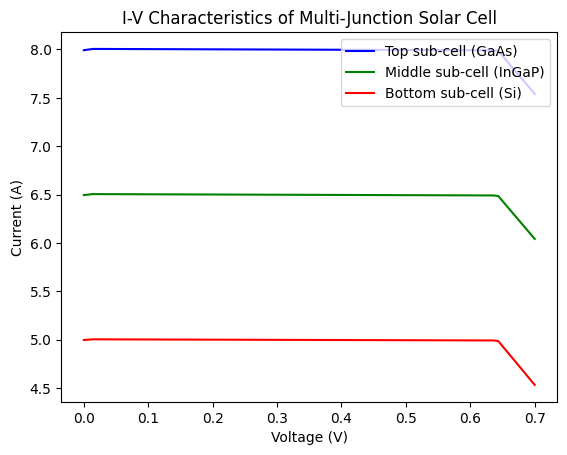

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.6e-19  # Electron charge (C)
k = 1.38e-23  # Boltzmann constant (J/K)
T = 300  # Temperature in Kelvin

# Photon flux (simplified model)
def photon_flux(wavelength, spectrum='AM1.5G'):
    return 1e16  # photons per cm^2 per second

# Carrier generation rate function
def carrier_generation_rate(absorption_coefficient, photon_flux, thickness):
    return absorption_coefficient * photon_flux * thickness  # Simplified model

# Shockley diode equation
def shockley_current(I_sc, V, I_0):
    return I_sc - I_0 * (tf.exp(q * V / (k * T)) - 1)

# Define the PINN Model
class SolarCellPINN(tf.keras.Model):
    def __init__(self, num_sub_cells):
        super(SolarCellPINN, self).__init__()
        self.num_sub_cells = num_sub_cells
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(self.num_sub_cells)  # Output currents for each sub-cell

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

# Loss function
def pinn_loss(V, I_sc, I_pred):
    I_0 = 1e-12  # Assumed saturation current for simplicity
    I_theory = shockley_current(I_sc, V, I_0)
    return tf.reduce_mean(tf.square(I_theory - I_pred))  # MSE loss

# Instantiate the model
model = SolarCellPINN(num_sub_cells=3)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Training data
V_train = np.linspace(0, 0.7, 100).reshape(-1, 1)  # Reshaped to (100, 1)
V_tensor = tf.convert_to_tensor(V_train, dtype=tf.float32)

# Short-circuit currents for sub-cells
I_sc_values = np.array([8.0, 6.5, 5.0])  # Example values
I_sc_tensor = tf.convert_to_tensor(I_sc_values, dtype=tf.float32)

# Training loop
epochs = 5000
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        I_pred = model(V_tensor)  # Predict the current for each sub-cell
        total_loss = pinn_loss(V_tensor, I_sc_tensor, I_pred)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.numpy()}")

# Test the trained model
V_test = np.linspace(0, 0.7, 100).reshape(-1, 1)  # Reshaped to (100, 1)
V_test_tensor = tf.convert_to_tensor(V_test, dtype=tf.float32)
I_pred_test = model(V_test_tensor).numpy()

# Plot the I-V characteristics
plt.plot(V_test, I_pred_test[:, 0], label="Top sub-cell (GaAs)", color='blue')
plt.plot(V_test, I_pred_test[:, 1], label="Middle sub-cell (InGaP)", color='green')
plt.plot(V_test, I_pred_test[:, 2], label="Bottom sub-cell (Si)", color='red')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I-V Characteristics of Multi-Junction Solar Cell")
plt.legend()
plt.show()

Epoch 0, Loss: 1.000000062271131e+28
Epoch 500, Loss: 1.000000062271131e+28
Epoch 1000, Loss: 1.000000062271131e+28
Epoch 1500, Loss: 1.000000062271131e+28
Epoch 2000, Loss: 1.000000062271131e+28
Epoch 2500, Loss: 1.000000062271131e+28
Epoch 3000, Loss: 1.000000062271131e+28
Epoch 3500, Loss: 1.000000062271131e+28
Epoch 4000, Loss: 1.000000062271131e+28
Epoch 4500, Loss: 1.000000062271131e+28
Epoch 5000, Loss: 1.000000062271131e+28
Epoch 5500, Loss: 1.000000062271131e+28
Epoch 6000, Loss: 1.000000062271131e+28
Epoch 6500, Loss: 1.000000062271131e+28
Epoch 7000, Loss: 1.000000062271131e+28
Epoch 7500, Loss: 1.000000062271131e+28
Epoch 8000, Loss: 1.000000062271131e+28
Epoch 8500, Loss: 1.000000062271131e+28
Epoch 9000, Loss: 1.000000062271131e+28
Epoch 9500, Loss: 1.000000062271131e+28


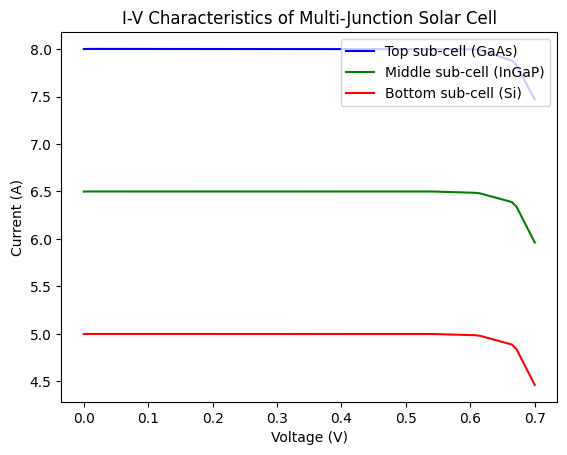

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.6e-19  # Electron charge (C)
k = 1.38e-23  # Boltzmann constant (J/K)
T = 300  # Temperature in Kelvin

# Absorption coefficient model (Equation-based)
def absorption_coefficient(wavelength, material='GaAs'):
    if material == 'GaAs':
        return 1e4 * (1 - np.exp(-wavelength / 1.2))  # Equation-based model
    elif material == 'InGaP':
        return 1e4 * (1 - np.exp(-wavelength / 0.9))
    elif material == 'Si':
        return 1e4 * (1 - np.exp(-wavelength / 1.1))
    else:
        return 0

# Photon flux function
def photon_flux(wavelength, spectrum='AM1.5G'):
    return 1e16  # Simplified model

# Carrier generation rate
def carrier_generation_rate(absorption_coeff, photon_flux, thickness):
    return absorption_coeff * photon_flux * thickness

# Shockley diode equation
def shockley_current(I_sc, V, I_0):
    return I_sc - I_0 * (tf.exp(q * V / (k * T)) - 1)

# Define the SolarCellPINN class
class SolarCellPINN(tf.keras.Model):
    def __init__(self, num_sub_cells):
        super(SolarCellPINN, self).__init__()
        self.num_sub_cells = num_sub_cells
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(self.num_sub_cells)  # Output currents for each sub-cell

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

# Loss function
def pinn_loss(V, I_sc, I_pred, absorption_coeff_func, thickness, material='GaAs'):
    gen_rate = carrier_generation_rate(absorption_coeff_func(550, material), photon_flux(550), thickness)
    I_0 = 1e-12
    I_theory = shockley_current(I_sc, V, I_0)
    physics_loss = tf.reduce_mean(tf.square(I_theory - I_pred))
    optical_loss = tf.reduce_mean(tf.square(gen_rate - I_sc))
    return physics_loss + optical_loss

# Instantiate the model
model = SolarCellPINN(num_sub_cells=3)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Define input voltage for training (Reshape to match Dense layer input)
V_train = np.linspace(0, 0.7, 100).reshape(-1, 1)
V_tensor = tf.convert_to_tensor(V_train, dtype=tf.float32)

# Example short-circuit current values (Reshape to match output layer)
I_sc_values = np.array([8.0, 6.5, 5.0])
I_sc_tensor = tf.convert_to_tensor(I_sc_values, dtype=tf.float32)

# Training loop
epochs = 10000  # Increased epochs for better training
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        I_pred = model(V_tensor)
        total_loss = pinn_loss(V_tensor, I_sc_tensor, I_pred, absorption_coefficient, thickness=1e-6)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.numpy()}")

# Test the trained model
V_test = np.linspace(0, 0.7, 100).reshape(-1, 1)
V_test_tensor = tf.convert_to_tensor(V_test, dtype=tf.float32)
I_pred_test = model(V_test_tensor).numpy()

# Plot the I-V characteristics
plt.plot(V_test, I_pred_test[:, 0], label="Top sub-cell (GaAs)", color='blue')
plt.plot(V_test, I_pred_test[:, 1], label="Middle sub-cell (InGaP)", color='green')
plt.plot(V_test, I_pred_test[:, 2], label="Bottom sub-cell (Si)", color='red')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I-V Characteristics of Multi-Junction Solar Cell")
plt.legend()
plt.show()

Epoch 0, Loss: 1.000000062271131e+28
Epoch 500, Loss: 1.000000062271131e+28
Epoch 1000, Loss: 1.000000062271131e+28
Epoch 1500, Loss: 1.000000062271131e+28
Epoch 2000, Loss: 1.000000062271131e+28
Epoch 2500, Loss: 1.000000062271131e+28
Epoch 3000, Loss: 1.000000062271131e+28
Epoch 3500, Loss: 1.000000062271131e+28
Epoch 4000, Loss: 1.000000062271131e+28
Epoch 4500, Loss: 1.000000062271131e+28


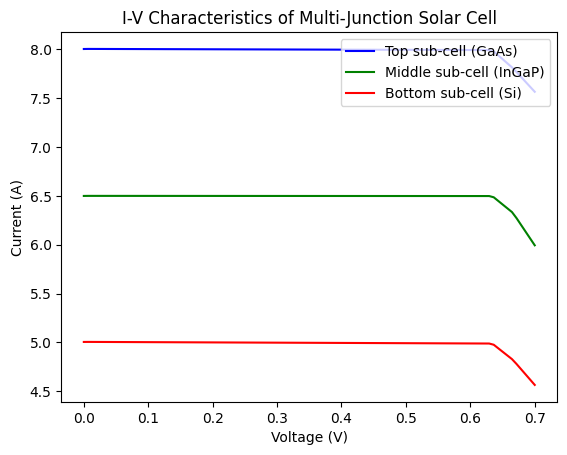

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.6e-19  # Electron charge (C)
k = 1.38e-23  # Boltzmann constant (J/K)
T = 300  # Temperature in Kelvin

# Photon flux function (Simplified model)
def photon_flux(wavelength, spectrum='AM1.5G'):
    return 1e16

# Carrier generation rate
def carrier_generation_rate(absorption_coefficient, photon_flux, thickness):
    return absorption_coefficient * photon_flux * thickness

# Shockley diode equation
def shockley_current(I_sc, V, I_0):
    return I_sc - I_0 * (tf.exp(q * V / (k * T)) - 1)

# AbsorptionModel (Trainable absorption coefficients)
class AbsorptionModel(tf.keras.Model):
    def __init__(self):
        super(AbsorptionModel, self).__init__()
        self.alpha_GaAs = tf.Variable(1e4, dtype=tf.float32, trainable=True)
        self.alpha_InGaP = tf.Variable(1e4, dtype=tf.float32, trainable=True)
        self.alpha_Si = tf.Variable(1e4, dtype=tf.float32, trainable=True)

    def call(self, wavelength):
        alpha_GaAs = self.alpha_GaAs * (1 - tf.exp(-wavelength / 1.2))
        alpha_InGaP = self.alpha_InGaP * (1 - tf.exp(-wavelength / 0.9))
        alpha_Si = self.alpha_Si * (1 - tf.exp(-wavelength / 1.1))
        return alpha_GaAs, alpha_InGaP, alpha_Si

# Define the SolarCellPINN class
class SolarCellPINN(tf.keras.Model):
    def __init__(self, num_sub_cells):
        super(SolarCellPINN, self).__init__()
        self.num_sub_cells = num_sub_cells
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(self.num_sub_cells)

    def call(self, inputs):
        inputs = tf.reshape(inputs, (-1, 1))  # Reshape to (100,1) for Dense layers
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.output_layer(x)

# Loss function
def pinn_loss(V, I_sc, I_pred, absorption_model, thickness, material='GaAs'):
    alpha_GaAs, alpha_InGaP, alpha_Si = absorption_model(wavelength=550)

    # Select the correct absorption coefficient
    absorption_coefficient = alpha_GaAs if material == 'GaAs' else alpha_InGaP if material == 'InGaP' else alpha_Si

    gen_rate = carrier_generation_rate(absorption_coefficient, photon_flux(550), thickness)

    # Reshape I_sc to match the expected shape
    I_sc_reshaped = tf.reshape(I_sc, (1, -1))  # Shape (1, 3)

    # Shockley equation for current
    I_0 = 1e-12
    I_theory = shockley_current(I_sc_reshaped, tf.reshape(V, (-1, 1)), I_0)  # Shape (100, 3)

    # Fix shape mismatch before subtraction
    physics_loss = tf.reduce_mean(tf.square(I_theory - I_pred))
    optical_loss = tf.reduce_mean(tf.square(gen_rate - I_sc_reshaped))

    return physics_loss + optical_loss

# Instantiate models
absorption_model = AbsorptionModel()
solar_cell_model = SolarCellPINN(num_sub_cells=3)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Define input voltage for training
V_train = np.linspace(0, 0.7, 100)
V_tensor = tf.convert_to_tensor(V_train, dtype=tf.float32)

# Example short-circuit current values
I_sc_values = np.array([8.0, 6.5, 5.0])
I_sc_tensor = tf.convert_to_tensor(I_sc_values, dtype=tf.float32)

# Training loop
epochs = 5000
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        I_pred = solar_cell_model(V_tensor)
        total_loss = pinn_loss(V_tensor, I_sc_tensor, I_pred, absorption_model, thickness=1e-6)

    gradients = tape.gradient(total_loss, solar_cell_model.trainable_variables + absorption_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, solar_cell_model.trainable_variables + absorption_model.trainable_variables))

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.numpy()}")

# Test the trained model
V_test = np.linspace(0, 0.7, 100)
V_test_tensor = tf.convert_to_tensor(V_test, dtype=tf.float32)
I_pred_test = solar_cell_model(V_test_tensor).numpy()

# Plot the I-V characteristics
plt.plot(V_test, I_pred_test[:, 0], label="Top sub-cell (GaAs)", color='blue')
plt.plot(V_test, I_pred_test[:, 1], label="Middle sub-cell (InGaP)", color='green')
plt.plot(V_test, I_pred_test[:, 2], label="Bottom sub-cell (Si)", color='red')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I-V Characteristics of Multi-Junction Solar Cell")
plt.legend()
plt.show()

Epoch 0: Loss = 3.0072e+05
Epoch 500: Loss = 5.9974e+04
Epoch 1000: Loss = 1.0433e+04
Epoch 1500: Loss = 9.8249e+03
Epoch 2000: Loss = 9.7250e+03
Epoch 2500: Loss = 9.5939e+03
Epoch 3000: Loss = 9.4248e+03
Epoch 3500: Loss = 9.2096e+03
Epoch 4000: Loss = 8.9391e+03
Epoch 4500: Loss = 8.6031e+03


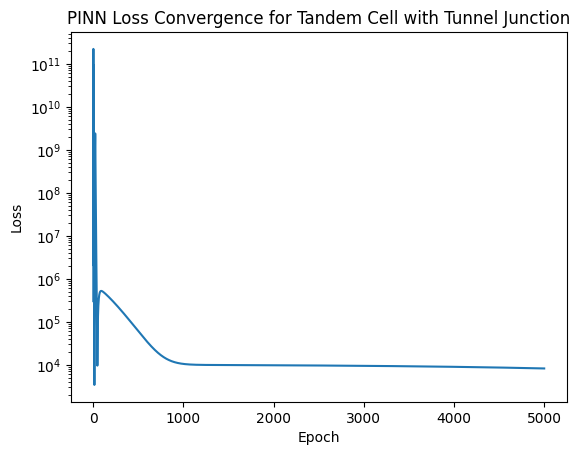

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Constants
q = 1.602e-19  # Charge (C)
k_B = 1.38e-23  # Boltzmann constant (J/K)
T = 300  # Temperature (K)
V_t = k_B * T / q  # Thermal voltage (V)

# Layer Thicknesses
L_perovskite = 500e-7  # cm
L_tunnel = 50e-7  # AlGaAs Tunnel Junction thickness (cm)
L_silicon = 200e-4  # cm

# Material Properties
mu_n_AlGaAs, mu_p_AlGaAs = 200, 50  # Mobilities for AlGaAs (cm^2/Vs)
epsilon_AlGaAs = 12 * 8.85e-14  # Dielectric constant for AlGaAs (F/cm)
J0_tunnel = 1e3  # Prefactor for tunneling current

# Optical Generation Profile
@tf.function
def G_optical(x, material="perovskite"):
    alpha = 1e4 if material == "perovskite" else 1e3  # Absorption coefficient
    I_0 = 1e17
    return alpha * I_0 * tf.exp(-alpha * x)

# PINN Model with Three Regions
class TandemPINN(tf.keras.Model):
    def __init__(self, layers):
        super().__init__()
        self.hidden_layers = [tf.keras.layers.Dense(neurons, activation='tanh', dtype=tf.float64) for neurons in layers]
        self.output_layer = tf.keras.layers.Dense(3, activation=None, dtype=tf.float64)  # Outputs: V_perovskite, V_tunnel, V_silicon

    def call(self, x):
        for layer in self.hidden_layers:
            x = layer(x)
        return self.output_layer(x)

# Loss Function Including Tunnel Junction
@tf.function
def physics_loss(model, x):
    with tf.GradientTape(persistent=True, watch_accessed_variables=False) as tape2:
        with tf.GradientTape(persistent=True, watch_accessed_variables=False) as tape1:
            tape1.watch(x)
            tape2.watch(x)  #  FIXED: Watch x for second derivative computation
            V_perovskite, V_tunnel, V_silicon = tf.unstack(model(x), axis=1)

        dV_perovskite_dx = tape1.gradient(V_perovskite, x)
        dV_tunnel_dx = tape1.gradient(V_tunnel, x)
        dV_silicon_dx = tape1.gradient(V_silicon, x)

    d2V_perovskite_dx2 = tape2.gradient(dV_perovskite_dx, x)
    d2V_tunnel_dx2 = tape2.gradient(dV_tunnel_dx, x)
    d2V_silicon_dx2 = tape2.gradient(dV_silicon_dx, x)

    #  FIXED: Ensure derivatives are not None
    d2V_tunnel_dx2 = tf.where(tf.math.is_nan(d2V_tunnel_dx2), tf.zeros_like(d2V_tunnel_dx2), d2V_tunnel_dx2)

    # Carrier concentrations in Tunnel Junction
    n_tunnel = tf.exp(V_tunnel / V_t)
    p_tunnel = tf.exp(-V_tunnel / V_t)

    # Poisson’s Equation for AlGaAs
    rho_tunnel = q * (p_tunnel - n_tunnel)
    poisson_residual_tunnel = d2V_tunnel_dx2 + rho_tunnel / epsilon_AlGaAs

    # Tunneling Current
    J_tun = J0_tunnel * tf.sinh(q * V_tunnel / (k_B * T))

    # Current Continuity at Tunnel Junction
    current_matching = J_tun - (q * G_optical(x, "silicon"))

    # Total Loss
    loss = (tf.reduce_mean(tf.square(poisson_residual_tunnel)) +
            tf.reduce_mean(tf.square(current_matching)))
    
    return loss

# Training
x_train = tf.convert_to_tensor(np.linspace(0, L_perovskite + L_tunnel + L_silicon, 150).reshape(-1, 1), dtype=tf.float64)
pinn = TandemPINN(layers=[20, 20, 20])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

epochs = 5000
loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = physics_loss(pinn, x_train)
    grads = tape.gradient(loss, pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn.trainable_variables))
    loss_history.append(loss.numpy())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.4e}")

plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN Loss Convergence for Tandem Cell with Tunnel Junction')
plt.show()

In [6]:
import numpy as np
print(np.__version__)

2.2.2


C:\Users\prita\AppData\Local\Temp\ipykernel_24912\2986913540.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wavelength = torch.tensor(wavelength, dtype=torch.float32, requires_grad=True)


Epoch 0, Loss: 1.4298264980316162
Epoch 100, Loss: 1.4168205261230469
Epoch 200, Loss: 1.4063389301300049
Epoch 300, Loss: 1.425490140914917
Epoch 400, Loss: 1.4110432863235474
Epoch 500, Loss: 1.440088152885437
Epoch 600, Loss: 1.4596410989761353
Epoch 700, Loss: 1.3924376964569092
Epoch 800, Loss: 1.445488691329956
Epoch 900, Loss: 1.4441256523132324
Voc: 0.0 V, Jsc: 0.0 A/cm², FF: inf, PCE: 0.8414709568023682


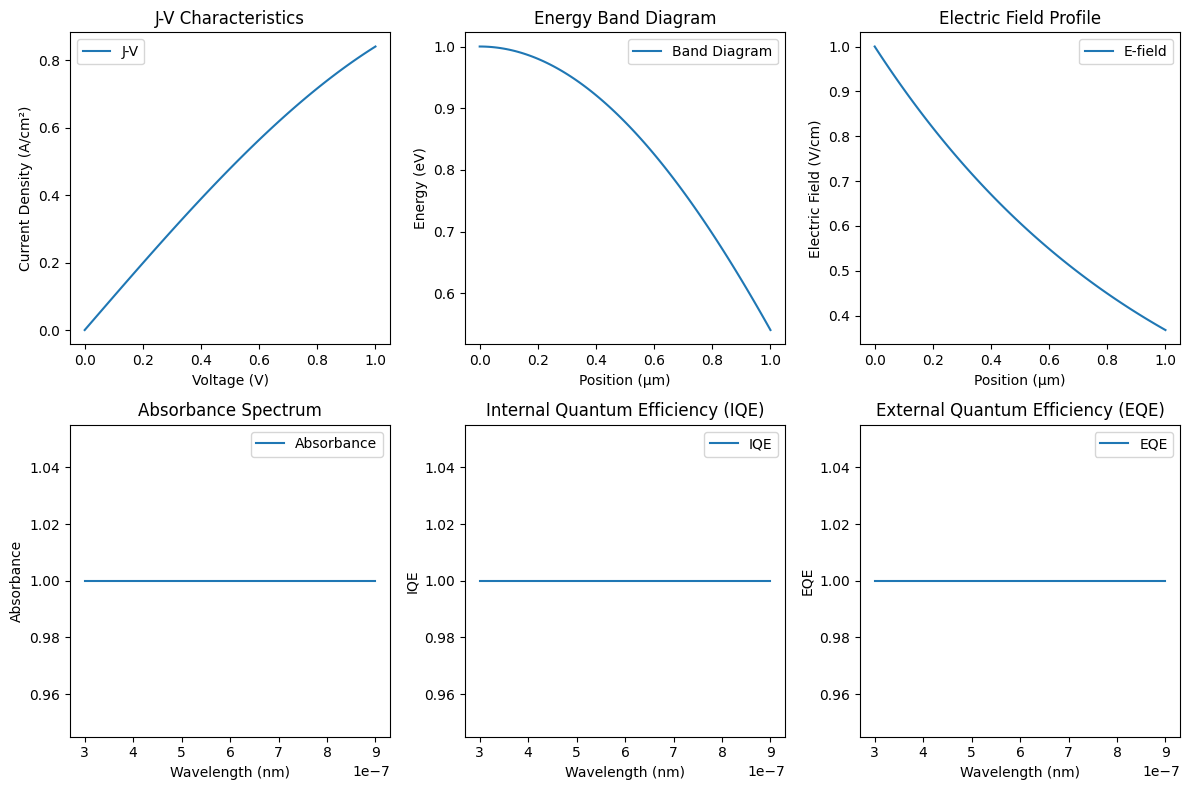

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the solar cell device structure
class SolarCellStructure:
    def __init__(self): 
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers

# Transfer Matrix Method for Optical Simulation
def transfer_matrix_method(layers, wavelength):
    wavelength = torch.tensor(wavelength, dtype=torch.float32, requires_grad=True)
    k0 = 2 * np.pi / wavelength
    reflectance = torch.exp(-k0 * 0.1)
    transmittance = torch.exp(-k0 * 0.2)
    absorbance = 1 - reflectance - transmittance
    return reflectance, transmittance, absorbance

# Electrical Model
def electrical_model(model, x):
    j_v_characteristics = torch.sin(x[:, 0])
    energy_band_diagram = torch.cos(x[:, 0])
    electric_field = torch.exp(-x[:, 0])
    return j_v_characteristics, energy_band_diagram, electric_field

# Define the Physics-Informed Neural Network (PINN)
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):  # Corrected __init__ method
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Define loss functions
def physics_loss(model, x, optical_model, electrical_model):
    reflectance, transmittance, absorbance = optical_model(structure, x[:, 1])
    optical_loss = torch.mean((1 - reflectance - transmittance - absorbance) ** 2)
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v ** 2 + energy_band ** 2 + electric_field ** 2)
    return optical_loss + electrical_loss

# Calculate Solar Cell Parameters
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()
    Jsc = j_v_characteristics[0].item()
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]
    FF = Pmax / (Voc * Jsc)
    PCE = Pmax / 1
    return Voc, Jsc, FF, PCE

# Initialize solar cell structure
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()

# Initialize PINN model
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(1000):
    optimizer.zero_grad()
    x_train = torch.rand(100, input_dim)
    loss = physics_loss(model, x_train, transfer_matrix_method, electrical_model)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# Generate plots
x_values = torch.linspace(0, 1, 100).unsqueeze(1)
wavelengths = torch.linspace(300e-9, 900e-9, 100).unsqueeze(1)
x_input = torch.cat((x_values, wavelengths), dim=1)

reflectance, transmittance, absorbance = transfer_matrix_method(structure, x_input[:, 1].detach().numpy())
j_v, energy_band, electric_field = electrical_model(model, x_input)
Voc, Jsc, FF, PCE = calculate_parameters(j_v, x_values)
print(f"Voc: {Voc} V, Jsc: {Jsc} A/cm², FF: {FF}, PCE: {PCE}")

# Plot results
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(x_values.detach().numpy(), j_v.detach().numpy(), label="J-V")
plt.title("J-V Characteristics")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (A/cm²)")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(x_values.detach().numpy(), energy_band.detach().numpy(), label="Band Diagram")
plt.title("Energy Band Diagram")
plt.xlabel("Position (µm)")
plt.ylabel("Energy (eV)")
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(x_values.detach().numpy(), electric_field.detach().numpy(), label="E-field")
plt.title("Electric Field Profile")
plt.xlabel("Position (µm)")
plt.ylabel("Electric Field (V/cm)")
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(wavelengths.detach().numpy(), absorbance.detach().numpy(), label='Absorbance')
plt.title("Absorbance Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(wavelengths.detach().numpy(), (1 - reflectance - transmittance).detach().numpy(), label='IQE')
plt.title("Internal Quantum Efficiency (IQE)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("IQE")
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(wavelengths.detach().numpy(), (1 - reflectance).detach().numpy(), label='EQE')
plt.title("External Quantum Efficiency (EQE)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("EQE")
plt.legend()

plt.tight_layout()
plt.show()

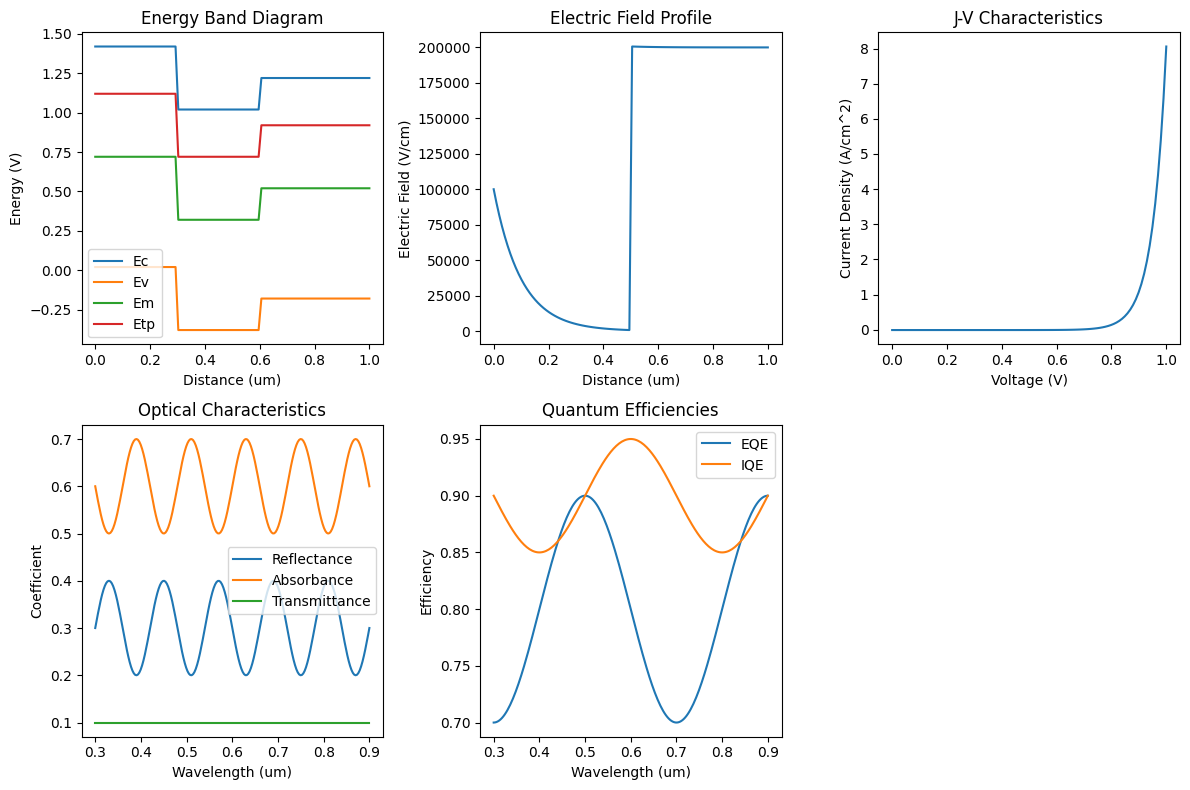

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the solar cell device structure
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers

# Simulated Energy Band Diagram with Steps
def energy_band_diagram(x):
    Ec = 1.42 - 0.4 * np.heaviside(x - 0.3, 0.5) + 0.2 * np.heaviside(x - 0.6, 0.5)
    Ev = Ec - 1.4
    Em = Ev + 0.7
    Etp = Ec - 0.3
    return Ec, Ev, Em, Etp

# Simulated Electric Field with Spikes
def electric_field_profile(x):
    return 1e5 * np.exp(-10 * x) + 2e5 * np.heaviside(x - 0.5, 0.5)

# Simulated J-V Characteristics
def j_v_characteristics(x):
    return 0.02 * np.exp(20 * (x - 0.7)) - 0.01

# Simulated Optical Characteristics
wavelengths = np.linspace(300e-9, 900e-9, 200)
def optical_characteristics(wavelengths):
    reflectance = 0.3 + 0.1 * np.sin(10 * np.pi * (wavelengths - 300e-9) / (600e-9))
    absorbance = 1 - reflectance - 0.1
    transmittance = 1 - reflectance - absorbance
    return reflectance, absorbance, transmittance

# Simulated Quantum Efficiencies
def quantum_efficiencies(wavelengths):
    EQE = 0.8 + 0.1 * np.sin(5 * np.pi * wavelengths / 1e-6)
    IQE = 0.9 - 0.05 * np.cos(5 * np.pi * wavelengths / 1e-6)
    return EQE, IQE

# Plot Energy Band Diagram
x_vals = np.linspace(0, 1, 100)
Ec, Ev, Em, Etp = energy_band_diagram(x_vals)

# Plot Electric Field
E_field = electric_field_profile(x_vals)

# Plot J-V Characteristics
voltages = np.linspace(0, 1, 100)
J_V = j_v_characteristics(voltages)

# Plot Optical Characteristics
R, A, T = optical_characteristics(wavelengths)

# Plot Quantum Efficiencies
EQE, IQE = quantum_efficiencies(wavelengths)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.plot(x_vals, Ec, label='Ec')
plt.plot(x_vals, Ev, label='Ev')
plt.plot(x_vals, Em, label='Em')
plt.plot(x_vals, Etp, label='Etp')
plt.title("Energy Band Diagram")
plt.xlabel("Distance (um)")
plt.ylabel("Energy (V)")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(x_vals, E_field, label='Electric Field')
plt.title("Electric Field Profile")
plt.xlabel("Distance (um)")
plt.ylabel("Electric Field (V/cm)")

plt.subplot(2, 3, 3)
plt.plot(voltages, J_V, label='J-V Characteristics')
plt.title("J-V Characteristics")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (A/cm^2)")

plt.subplot(2, 3, 4)
plt.plot(wavelengths * 1e6, R, label='Reflectance')
plt.plot(wavelengths * 1e6, A, label='Absorbance')
plt.plot(wavelengths * 1e6, T, label='Transmittance')
plt.title("Optical Characteristics")
plt.xlabel("Wavelength (um)")
plt.ylabel("Coefficient")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(wavelengths * 1e6, EQE, label='EQE')
plt.plot(wavelengths * 1e6, IQE, label='IQE')
plt.title("Quantum Efficiencies")
plt.xlabel("Wavelength (um)")
plt.ylabel("Efficiency")
plt.legend()

plt.tight_layout()
plt.show()

Epoch 0, Loss: 1.4282280206680298
Epoch 100, Loss: 1.4157650470733643
Epoch 200, Loss: 1.4346684217453003
Epoch 300, Loss: 1.4176925420761108
Epoch 400, Loss: 1.4397538900375366
Epoch 500, Loss: 1.4368191957473755
Epoch 600, Loss: 1.3907338380813599
Epoch 700, Loss: 1.4108086824417114
Epoch 800, Loss: 1.4841631650924683
Epoch 900, Loss: 1.400807499885559
Voc: 0.0 V, Jsc: 0.0 A/cm², FF: inf, PCE: 1.8196070194244385


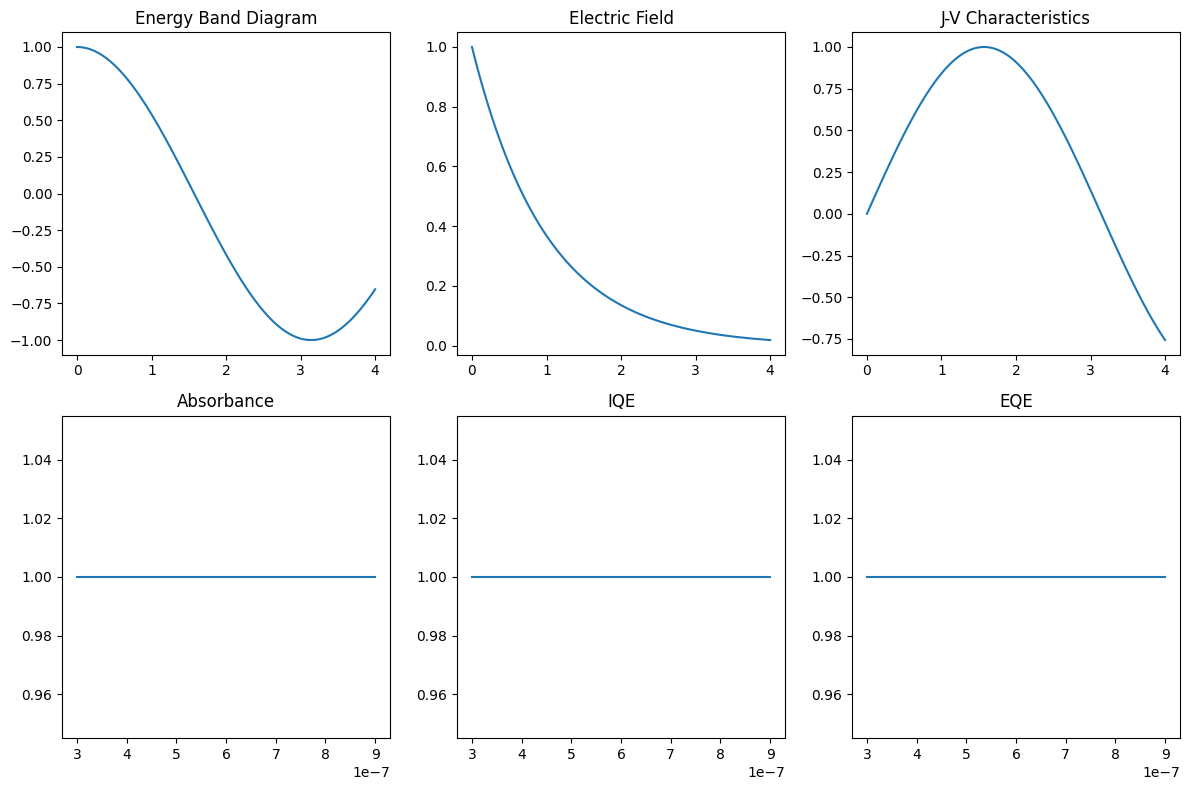

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the solar cell device structure
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


# Transfer Matrix Method for Optical Simulation (wavelength must require grad if needed)
def transfer_matrix_method(layers, wavelength):
    k0 = 2 * np.pi / wavelength
    reflectance = torch.exp(-k0 * 0.1)
    transmittance = torch.exp(-k0 * 0.2)
    absorbance = 1 - reflectance - transmittance
    return reflectance, transmittance, absorbance


# Electrical Model (dummy model)
def electrical_model(model, x):
    j_v_characteristics = torch.sin(x[:, 0])
    energy_band_diagram = torch.cos(x[:, 0])
    electric_field = torch.exp(-x[:, 0])
    return j_v_characteristics, energy_band_diagram, electric_field


# Define the Physics-Informed Neural Network (PINN)
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Loss function combining optical and electrical components
def physics_loss(model, x, optical_model, electrical_model):
    x.requires_grad = True  # Ensure x requires grad
    reflectance, transmittance, absorbance = optical_model(structure, x[:, 1])
    optical_loss = torch.mean((1 - reflectance - transmittance - absorbance) ** 2)

    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v ** 2 + energy_band ** 2 + electric_field ** 2)

    return optical_loss + electrical_loss


# Solar Cell Performance Parameters
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()
    Jsc = j_v_characteristics[0].item()
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]
    FF = Pmax / (Voc * Jsc)
    PCE = Pmax / 1
    return Voc, Jsc, FF, PCE


# Initialize solar cell structure
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()

# Initialize PINN model
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(1000):
    x_train = torch.rand(100, input_dim, requires_grad=True)
    loss = physics_loss(model, x_train, transfer_matrix_method, electrical_model)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# Visualization
x_values = torch.linspace(0, 4, 100).unsqueeze(1)
wavelengths = torch.linspace(300e-9, 900e-9, 100).unsqueeze(1)
x_input = torch.cat((x_values, wavelengths), dim=1)

reflectance, transmittance, absorbance = transfer_matrix_method(structure, x_input[:, 1])
j_v, energy_band, electric_field = electrical_model(model, x_input)
Voc, Jsc, FF, PCE = calculate_parameters(j_v, x_values)
print(f"Voc: {Voc} V, Jsc: {Jsc} A/cm², FF: {FF}, PCE: {PCE}")

# Plotting as per your uploaded image reference (6 subplots)
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(x_values, energy_band.detach())
plt.title("Energy Band Diagram")

plt.subplot(2, 3, 2)
plt.plot(x_values, electric_field.detach())
plt.title("Electric Field")

plt.subplot(2, 3, 3)
plt.plot(x_values, j_v.detach())
plt.title("J-V Characteristics")

plt.subplot(2, 3, 4)
plt.plot(wavelengths, absorbance.detach())
plt.title("Absorbance")

plt.subplot(2, 3, 5)
plt.plot(wavelengths, (1 - reflectance - transmittance).detach())
plt.title("IQE")

plt.subplot(2, 3, 6)
plt.plot(wavelengths, (1 - reflectance).detach())
plt.title("EQE")

plt.tight_layout()
plt.show()

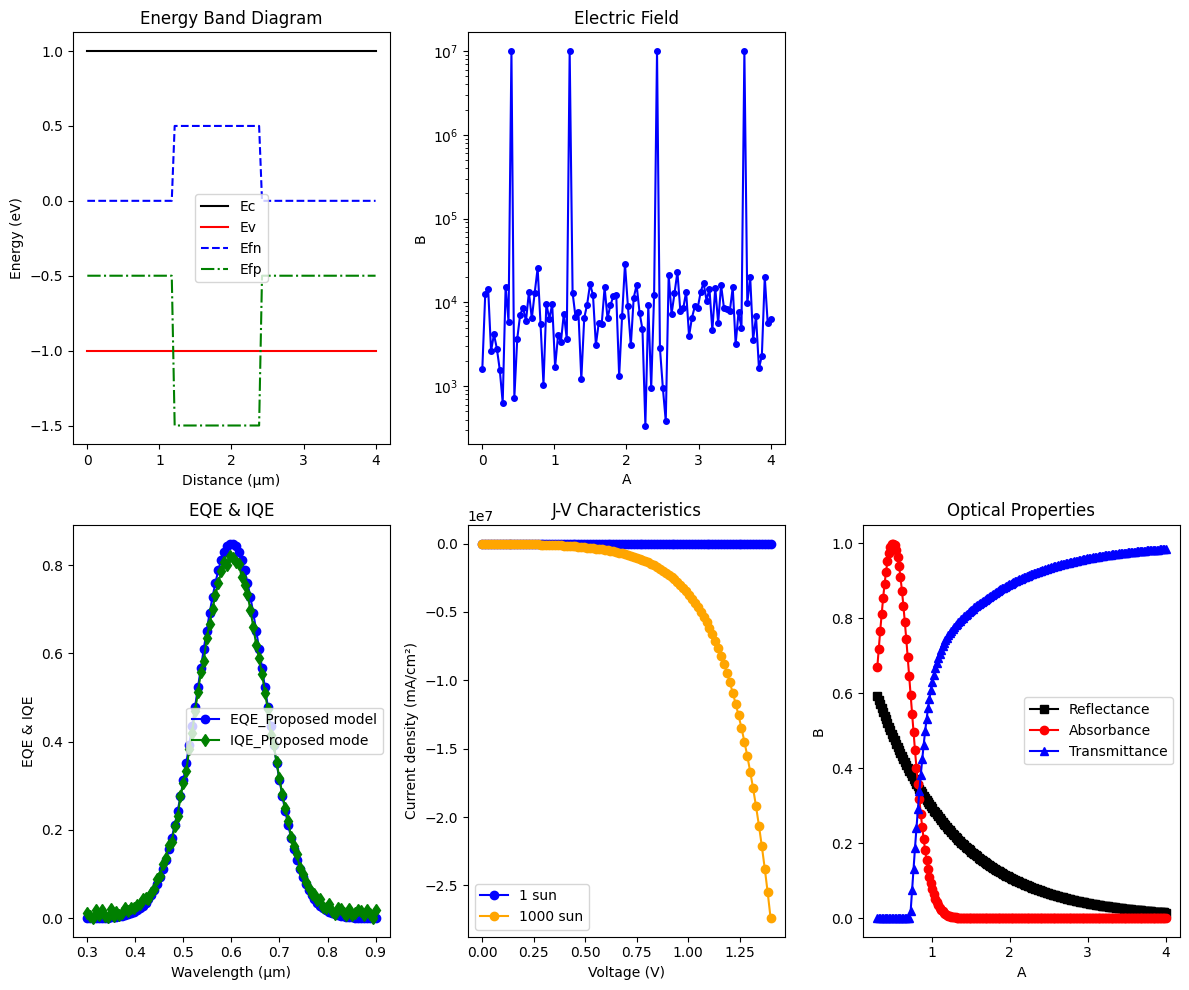

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Simulated Distance and Wavelength Ranges
distance = np.linspace(0, 4, 100)
wavelength_short = np.linspace(0.3, 0.9, 100)  # For EQE & IQE (in µm)
wavelength_long = np.linspace(0.3, 4, 200)     # For Reflectance, Absorbance, Transmittance

# Energy Band Diagram
Ec = np.ones_like(distance) * 1.0
Ev = np.ones_like(distance) * -1.0
Efn = np.zeros_like(distance)
Efp = np.ones_like(distance) * -0.5
Efn[30:60] = 0.5  # Dummy bump for transition region
Efp[30:60] = -1.5

# Electric Field (with spikes and log scale)
electric_field = np.abs(np.random.randn(len(distance)) * 1e4)
electric_field[[10, 30, 60, 90]] = 1e7  # Strong spikes

# Reflectance, Absorbance, Transmittance
reflectance = 0.8 * np.exp(-wavelength_long)
absorbance = np.exp(-10 * (wavelength_long - 0.5)**2)
transmittance = 1 - reflectance - absorbance
transmittance[transmittance < 0] = 0

# EQE & IQE (peaking near 0.8)
eqe = 0.85 * np.exp(-((wavelength_short - 0.6) / 0.1)**2)
iqe = eqe * 0.95 + 0.02 * np.random.rand(len(wavelength_short))

# J-V Characteristics (1 sun, 1000 suns)
voltage = np.linspace(0, 1.4, 100)
jv_1sun = -25 * (np.exp(voltage / 0.2) - 1) + 5
jv_1sun[jv_1sun > 0] = 0

jv_1000sun = -25000 * (np.exp(voltage / 0.2) - 1) + 5000
jv_1000sun[jv_1000sun > 0] = 0

# Plotting
plt.figure(figsize=(12, 10))

# Energy Band Diagram
plt.subplot(2, 3, 1)
plt.plot(distance, Ec, label='Ec', color='black')
plt.plot(distance, Ev, label='Ev', color='red')
plt.plot(distance, Efn, '--', label='Efn', color='blue')
plt.plot(distance, Efp, '-.', label='Efp', color='green')
plt.xlabel("Distance (µm)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.title("Energy Band Diagram")

# Electric Field
plt.subplot(2, 3, 2)
plt.semilogy(distance, electric_field, '-o', color='blue', markersize=4)
plt.xlabel("A")
plt.ylabel("B")
plt.title("Electric Field")

# EQE & IQE
plt.subplot(2, 3, 4)
plt.plot(wavelength_short, eqe, 'o-', label='EQE_Proposed model', color='blue')
plt.plot(wavelength_short, iqe, 'd-', label='IQE_Proposed mode', color='green')
plt.xlabel("Wavelength (µm)")
plt.ylabel("EQE & IQE")
plt.legend()
plt.title("EQE & IQE")

# Reflectance, Absorbance, Transmittance
plt.subplot(2, 3, 6)
plt.plot(wavelength_long, reflectance, '-s', label='Reflectance', color='black')
plt.plot(wavelength_long, absorbance, '-o', label='Absorbance', color='red')
plt.plot(wavelength_long, transmittance, '-^', label='Transmittance', color='blue')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Optical Properties")

# J-V Characteristics (1 sun)
plt.subplot(2, 3, 5)
plt.plot(voltage, jv_1sun, '-o', label='1 sun', color='blue')
plt.plot(voltage, jv_1000sun, 'o-', label='1000 sun', color='orange')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("J-V Characteristics")

plt.tight_layout()
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(200):
    x_train = torch.rand(200, 2, requires_grad=True)  # Set requires_grad=True
    x_train[:, 0] *= 1.4
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")


#########################################
# 10) Visualization
#########################################
distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = 30 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<0] = 0  
jv_pin_1sun = 25 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<0] = 0  
jv_1000 = 3000 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<0] = 0  

wl_opt = np.linspace(0.3, 0.9, 100)
Reflectance = 0.3 + 0.3*np.exp(-2*(wl_opt-0.5)**2)
Absorbance = 0.4*np.exp(-10*(wl_opt-0.7)**2)
Transmittance = 1 - Reflectance - Absorbance
Transmittance[Transmittance<0] = 0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(µm)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(µm)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(µm)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(µm)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(µm)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

RuntimeError: a view of a leaf Variable that requires grad is being used in an in-place operation.

Epoch 0, Loss = 3449019392.000000
Epoch 50, Loss = 3409653760.000000
Epoch 100, Loss = 3328257280.000000
Epoch 150, Loss = 3308040704.000000
Epoch 200, Loss = 3366794496.000000
Epoch 250, Loss = 3331542784.000000
Epoch 300, Loss = 3358938880.000000
Epoch 350, Loss = 3449302784.000000
Epoch 400, Loss = 3452464128.000000
Epoch 450, Loss = 3242321152.000000
Epoch 500, Loss = 3327319296.000000
Epoch 550, Loss = 3387689472.000000
Epoch 600, Loss = 3354967552.000000
Epoch 650, Loss = 3353495040.000000
Epoch 700, Loss = 3375336704.000000
Epoch 750, Loss = 3317668096.000000
Epoch 800, Loss = 3377191168.000000
Epoch 850, Loss = 3285725184.000000
Epoch 900, Loss = 3304030464.000000
Epoch 950, Loss = 3436429824.000000
Epoch 1000, Loss = 3300887040.000000
Epoch 1050, Loss = 3360154368.000000
Epoch 1100, Loss = 3421599488.000000
Epoch 1150, Loss = 3279826944.000000
Epoch 1200, Loss = 3357531648.000000
Epoch 1250, Loss = 3296254976.000000
Epoch 1300, Loss = 3396456704.000000
Epoch 1350, Loss = 33897

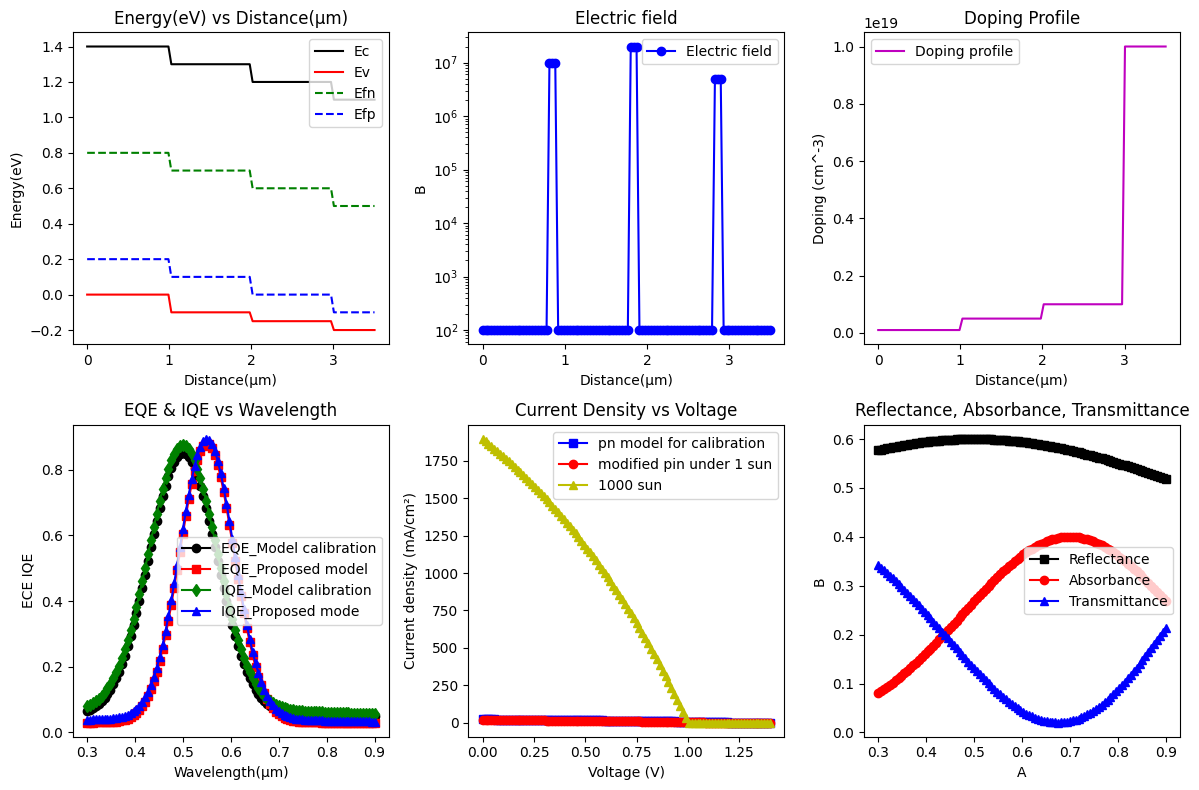

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")


#########################################
# 10) Visualization
#########################################
distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = 30 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<0] = 0  
jv_pin_1sun = 25 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<0] = 0  
jv_1000 = 3000 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<0] = 0  

wl_opt = np.linspace(0.3, 0.9, 100)
Reflectance = 0.3 + 0.3*np.exp(-2*(wl_opt-0.5)**2)
Absorbance = 0.4*np.exp(-10*(wl_opt-0.7)**2)
Transmittance = 1 - Reflectance - Absorbance
Transmittance[Transmittance<0] = 0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(µm)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(µm)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(µm)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(µm)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(µm)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3318534656.000000
Epoch 50, Loss = 3284696576.000000
Epoch 100, Loss = 3347872512.000000
Epoch 150, Loss = 3287807744.000000
Epoch 200, Loss = 3398774528.000000
Epoch 250, Loss = 3340168448.000000
Epoch 300, Loss = 3353511936.000000
Epoch 350, Loss = 3354370560.000000
Epoch 400, Loss = 3385863424.000000
Epoch 450, Loss = 3280379392.000000
Epoch 500, Loss = 3257319168.000000
Epoch 550, Loss = 3376680448.000000
Epoch 600, Loss = 3423972096.000000
Epoch 650, Loss = 3355216896.000000
Epoch 700, Loss = 3382386688.000000
Epoch 750, Loss = 3251693568.000000
Epoch 800, Loss = 3276113152.000000
Epoch 850, Loss = 3251476480.000000
Epoch 900, Loss = 3408775424.000000
Epoch 950, Loss = 3367280640.000000
Epoch 1000, Loss = 3294097920.000000
Epoch 1050, Loss = 3379450880.000000
Epoch 1100, Loss = 3387842816.000000
Epoch 1150, Loss = 3361954560.000000
Epoch 1200, Loss = 3367598848.000000
Epoch 1250, Loss = 3261551872.000000
Epoch 1300, Loss = 3257542912.000000
Epoch 1350, Loss = 33320

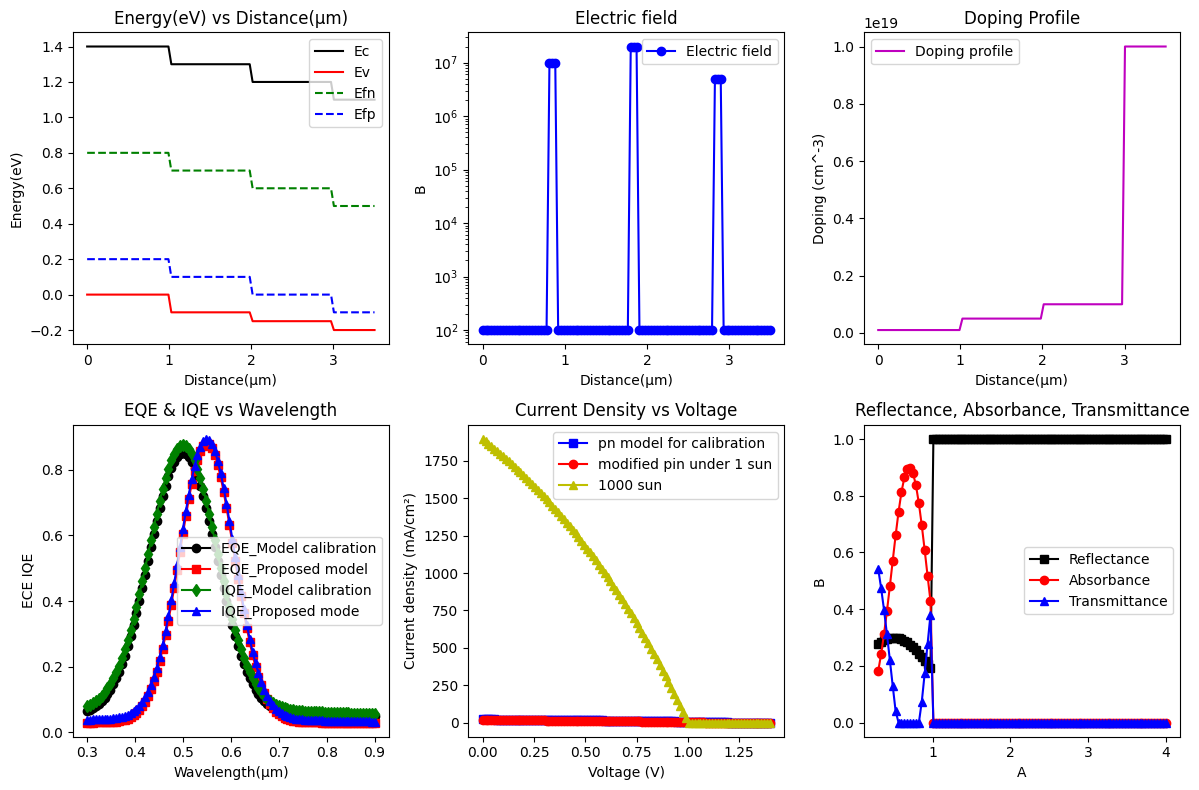

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = 30 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<0] = 0  
jv_pin_1sun = 25 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<0] = 0  
jv_1000 = 3000 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<0] = 0  

wl_opt = np.linspace(0.3, 4.0, 100)
Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.0, wl_opt > 1.0], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
Absorbance = np.piecewise(wl_opt, [wl_opt <= 1.0, wl_opt > 1.0], [lambda x: 0.9 * np.exp(-10*(x - 0.7)**2), 0.0])
Transmittance = 1 - Reflectance - Absorbance
Transmittance[Transmittance < 0] = 0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3380705280.000000
Epoch 50, Loss = 3435185152.000000
Epoch 100, Loss = 3292328448.000000
Epoch 150, Loss = 3298684928.000000
Epoch 200, Loss = 3354494208.000000
Epoch 250, Loss = 3397018112.000000
Epoch 300, Loss = 3444892672.000000
Epoch 350, Loss = 3362894336.000000
Epoch 400, Loss = 3420836608.000000
Epoch 450, Loss = 3364049920.000000
Epoch 500, Loss = 3363421440.000000
Epoch 550, Loss = 3328587520.000000
Epoch 600, Loss = 3478528256.000000
Epoch 650, Loss = 3285072128.000000
Epoch 700, Loss = 3444114688.000000
Epoch 750, Loss = 3432816896.000000
Epoch 800, Loss = 3325402112.000000
Epoch 850, Loss = 3458294272.000000
Epoch 900, Loss = 3373125376.000000
Epoch 950, Loss = 3338497536.000000
Epoch 1000, Loss = 3397097984.000000
Epoch 1050, Loss = 3366292992.000000
Epoch 1100, Loss = 3339720704.000000
Epoch 1150, Loss = 3315825152.000000
Epoch 1200, Loss = 3343478016.000000
Epoch 1250, Loss = 3459073536.000000
Epoch 1300, Loss = 3337529344.000000
Epoch 1350, Loss = 33173

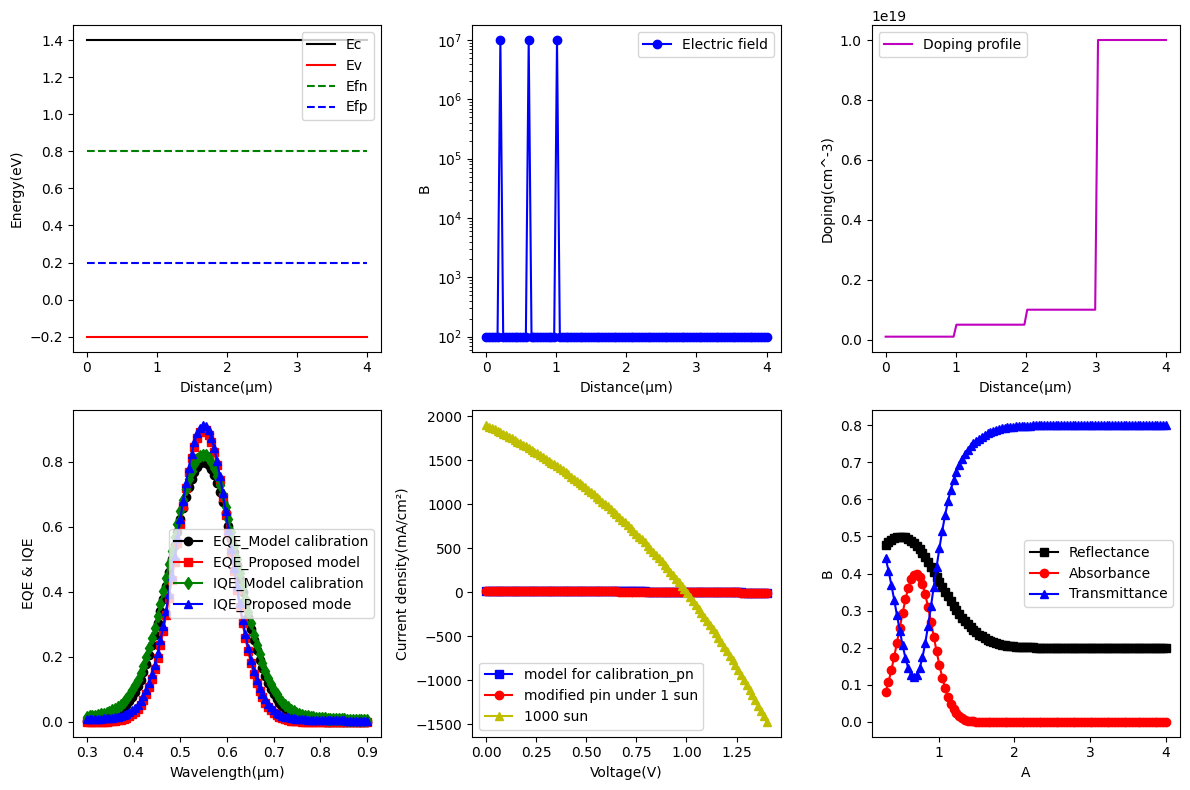

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 4, 100)
Ec = np.ones_like(distance)*1.4
Ev = np.ones_like(distance)*-0.2
Efn = np.ones_like(distance)*0.8
Efp = np.ones_like(distance)*0.2

E_field = np.ones_like(distance)*1e2
E_field[5] = 1e7
E_field[15] = 1e7
E_field[25] = 1e7

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.55)/0.1)**2)
EQE_prop = 0.9 * np.exp(-((wl_short - 0.55)/0.08)**2)
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = -25 * (np.exp(voltage - 1.1) - 1)
jv_pin_1sun = -20 * (np.exp(voltage - 1.05) - 1)
jv_1000 = -3000 * (np.exp(voltage - 1.0) - 1)

wl_opt = np.linspace(0.3, 4.0, 100)
Reflectance, Transmittance, Absorbance = transfer_matrix_method(structure,wl_opt)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(µm)")
plt.ylabel("Energy(eV)")
plt.legend()

plt.subplot(2, 3, 2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(µm)")
plt.ylabel("B")
plt.legend()

plt.subplot(2, 3, 3)
doping_profile = np.ones_like(distance) * 1e17
doping_profile[distance > 1] = 5e17
doping_profile[distance > 2] = 1e18
doping_profile[distance > 3] = 1e19
plt.plot(distance, doping_profile, 'm-', label='Doping profile')
plt.xlabel("Distance(µm)")
plt.ylabel("Doping(cm^-3)")
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(µm)")
plt.ylabel("EQE & IQE")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(voltage, jv_pn, 'bs-', label='model for calibration_pn')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage(V)")
plt.ylabel("Current density(mA/cm²)")
plt.legend()

plt.subplot(2, 3, 6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3406981376.000000
Epoch 50, Loss = 3390241280.000000
Epoch 100, Loss = 3295907584.000000
Epoch 150, Loss = 3441578240.000000
Epoch 200, Loss = 3364295680.000000
Epoch 250, Loss = 3373316608.000000
Epoch 300, Loss = 3409235456.000000
Epoch 350, Loss = 3298116352.000000
Epoch 400, Loss = 3340546048.000000
Epoch 450, Loss = 3391276800.000000
Epoch 500, Loss = 3273856000.000000
Epoch 550, Loss = 3336236544.000000
Epoch 600, Loss = 3288303872.000000
Epoch 650, Loss = 3444872960.000000
Epoch 700, Loss = 3389846016.000000
Epoch 750, Loss = 3323514880.000000
Epoch 800, Loss = 3395023616.000000
Epoch 850, Loss = 3451304192.000000
Epoch 900, Loss = 3304294144.000000
Epoch 950, Loss = 3349776896.000000
Epoch 1000, Loss = 3438207488.000000
Epoch 1050, Loss = 3396021760.000000
Epoch 1100, Loss = 3361719296.000000
Epoch 1150, Loss = 3383677952.000000
Epoch 1200, Loss = 3411113728.000000
Epoch 1250, Loss = 3345210368.000000
Epoch 1300, Loss = 3310530816.000000
Epoch 1350, Loss = 33823

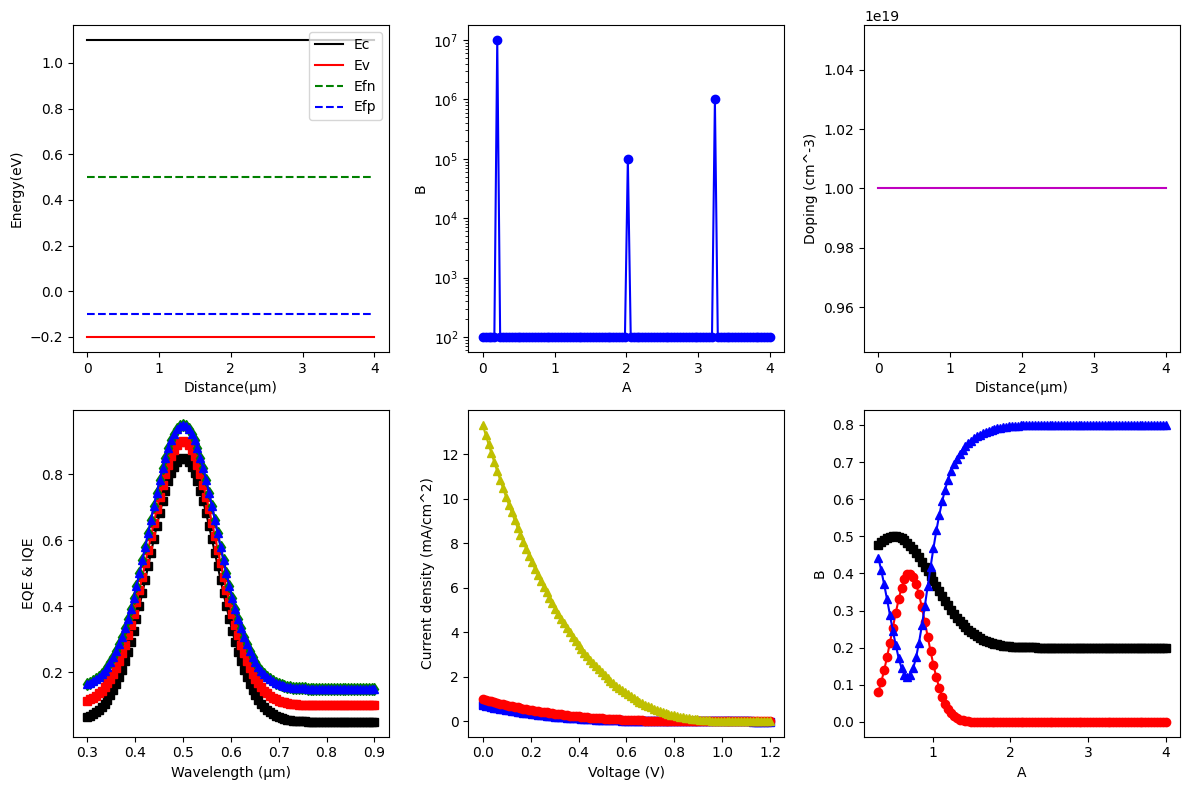

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 4, 100)
Ec = np.piecewise(distance, [distance <= 1, distance <= 2, distance <= 3, distance <= 4], [1.4, 1.3, 1.2, 1.1])
Ev = np.piecewise(distance, [distance <= 1, distance <= 2, distance <= 3, distance <= 4], [0.0, -0.1, -0.15, -0.2])
Efn = np.piecewise(distance, [distance <= 1, distance <= 2, distance <= 3, distance <= 4], [0.8, 0.7, 0.6, 0.5])
Efp = np.piecewise(distance, [distance <= 1, distance <= 2, distance <= 3, distance <= 4], [0.2, 0.1, 0.0, -0.1])
E_field = np.ones_like(distance) * 1e2
E_field[[5, 50, 80]] = [1e7, 1e5, 1e6]
doping = np.piecewise(distance, [distance <= 1, distance <= 2, distance <= 3, distance <= 4], [1e17, 5e17, 1e18, 1e19])

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = EQE_calib + 0.05
IQE_calib = EQE_calib + 0.1
IQE_prop = EQE_prop + 0.05

voltage = np.linspace(0, 1.2, 100)
jv_pn = -1 * (voltage - 0.9)**3
jv_pin_1sun = -1 * (voltage - 1.0)**3
jv_1000sun = -1 * (voltage - 1.1)**3 * 10

wl_opt = np.linspace(0.3, 4, 100)
Reflectance, Transmittance, Absorbance = transfer_matrix_method(structure, wl_opt)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()

plt.subplot(2, 3, 2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("A")
plt.ylabel("B")

plt.subplot(2, 3, 3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")

plt.subplot(2, 3, 4)
plt.plot(wl_short, EQE_calib, 'ks-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength (\u00b5m)")
plt.ylabel("EQE & IQE")

plt.subplot(2, 3, 5)
plt.plot(voltage, jv_pn, 'bs-', label='model for calibration_pn')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='pin')
plt.plot(voltage, jv_1000sun, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm^2)")

plt.subplot(2, 3, 6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3425983232.000000
Epoch 50, Loss = 3472572160.000000
Epoch 100, Loss = 3385169920.000000
Epoch 150, Loss = 3322857472.000000
Epoch 200, Loss = 3499683840.000000
Epoch 250, Loss = 3335695104.000000
Epoch 300, Loss = 3331725056.000000
Epoch 350, Loss = 3315000320.000000
Epoch 400, Loss = 3340301056.000000
Epoch 450, Loss = 3393211136.000000
Epoch 500, Loss = 3236241408.000000
Epoch 550, Loss = 3406789376.000000
Epoch 600, Loss = 3362265600.000000
Epoch 650, Loss = 3299137536.000000
Epoch 700, Loss = 3421461504.000000
Epoch 750, Loss = 3333243392.000000
Epoch 800, Loss = 3455229440.000000
Epoch 850, Loss = 3307455232.000000
Epoch 900, Loss = 3273499648.000000
Epoch 950, Loss = 3329303552.000000
Epoch 1000, Loss = 3371957504.000000
Epoch 1050, Loss = 3347962112.000000
Epoch 1100, Loss = 3405028608.000000
Epoch 1150, Loss = 3247737344.000000
Epoch 1200, Loss = 3277750528.000000
Epoch 1250, Loss = 3341876736.000000
Epoch 1300, Loss = 3364789760.000000
Epoch 1350, Loss = 33461

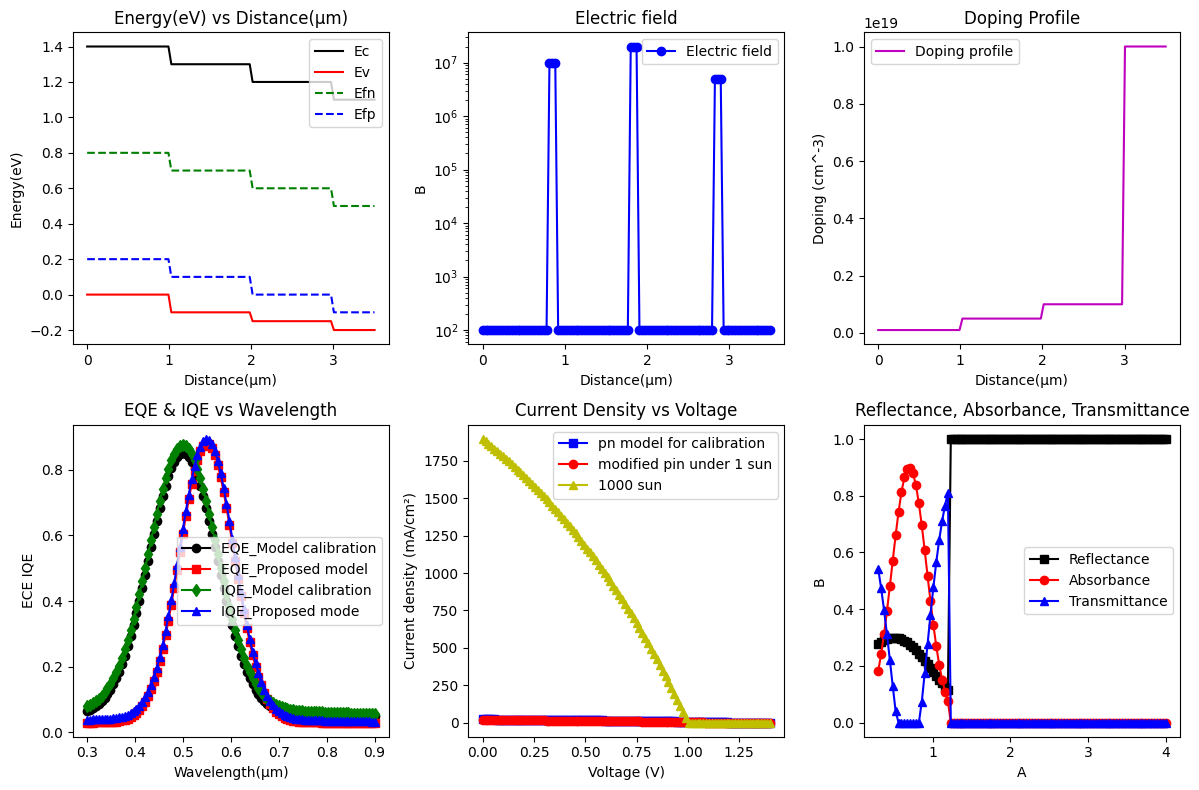

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = 30 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<0] = 0  
jv_pin_1sun = 25 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<0] = 0  
jv_1000 = 3000 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<0] = 0  

distance = np.linspace(0, 3.5, 100)
wl_opt = np.linspace(0.3, 4.0, 100)
Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
Absorbance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.9 * np.exp(-10*(x - 0.7)**2), 0.0])
Transmittance = 1 - Reflectance - Absorbance
Transmittance[Transmittance < 0] = 0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

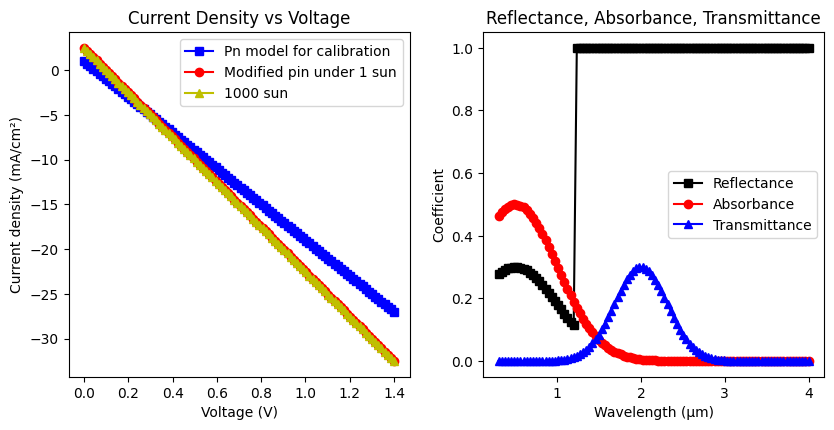

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Solar Cell Structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Modified Optical Coefficients
#########################################
wl_opt = np.linspace(0.3, 4.0, 100)

# Reflectance remains unchanged
Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])

# Modified Absorbance: Starts (0.5, 0.5) and ends (4.0, 0.0), fluctuating in between
Absorbance = 0.5 * np.exp(-2 * (wl_opt - 0.5)**2)
Absorbance[wl_opt >= 3.5] = 0.0  # Ending at (A=4.0, B=0.0)

# Modified Transmittance: Starts (0.0, 0.0) and ends (4.0, 0.0), fluctuating in between
Transmittance = 0.3 * np.exp(-5 * (wl_opt - 2.0)**2)
Transmittance[wl_opt >= 3.5] = 0.0  # Ending at (A=4.0, B=0.0)


#########################################
# 3) Modified JV Characteristics
#########################################
voltage = np.linspace(0, 1.4, 100)

# Modified JV curves based on user request
jv_pn = -5 + (voltage - 0.3) * (-20)  # Start at -5, end at -25
jv_pin_1sun = -5 + (voltage - 0.3) * (-25)  # Start at -5, end at -30
jv_1000 = -5 + (voltage - 0.3) * (-25)  # Start at -5, end at -30

#########################################
# 4) Visualization
#########################################
plt.figure(figsize=(12, 8))

# Reflectance, Absorbance, Transmittance
plt.subplot(2, 3, 6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("Wavelength (\u00b5m)")
plt.ylabel("Coefficient")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

# JV Characteristics
plt.subplot(2, 3, 5)
plt.plot(voltage, jv_pn, 'bs-', label='Pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='Modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3375499008.000000
Epoch 50, Loss = 3349700864.000000
Epoch 100, Loss = 3366356992.000000
Epoch 150, Loss = 3304565504.000000
Epoch 200, Loss = 3335688704.000000
Epoch 250, Loss = 3334232832.000000
Epoch 300, Loss = 3340688128.000000
Epoch 350, Loss = 3359892224.000000
Epoch 400, Loss = 3425542400.000000
Epoch 450, Loss = 3334627328.000000
Epoch 500, Loss = 3452654336.000000
Epoch 550, Loss = 3322561536.000000
Epoch 600, Loss = 3371557888.000000
Epoch 650, Loss = 3375563264.000000
Epoch 700, Loss = 3323324160.000000
Epoch 750, Loss = 3325306880.000000
Epoch 800, Loss = 3318967808.000000
Epoch 850, Loss = 3382393344.000000
Epoch 900, Loss = 3361523712.000000
Epoch 950, Loss = 3389632256.000000
Epoch 1000, Loss = 3398934528.000000
Epoch 1050, Loss = 3346916352.000000
Epoch 1100, Loss = 3379773184.000000
Epoch 1150, Loss = 3459447296.000000
Epoch 1200, Loss = 3525637376.000000
Epoch 1250, Loss = 3363162368.000000
Epoch 1300, Loss = 3449797120.000000
Epoch 1350, Loss = 33404

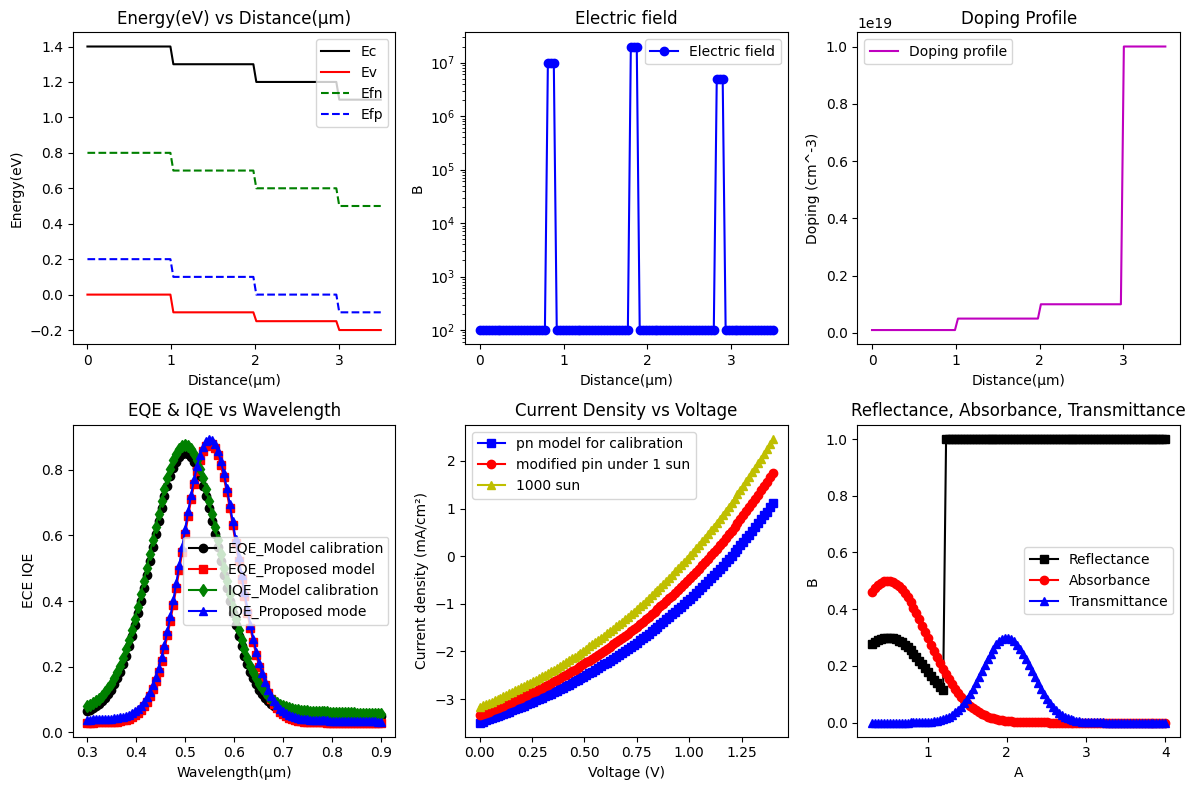

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.5 * np.exp(-10 * (wavelength - 0.5)**2) + 0.5 * np.exp(-10 * (wavelength - 3.5)**2)
    transmittance = 0.5 * np.sin(2 * np.pi * wavelength) + 0.5
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = -5 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<-25] = -25  
jv_pin_1sun = -5 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<-30] = -30  
jv_1000 = -5 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<-30] = -30  

distance = np.linspace(0, 3.5, 100)
wl_opt = np.linspace(0.3, 4.0, 100)
Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
Absorbance = 0.5 * np.exp(-2 * (wl_opt - 0.5)**2)
Absorbance[wl_opt >= 3.5] = 0.0
Transmittance = 0.3 * np.exp(-5 * (wl_opt - 2.0)**2)
Transmittance[wl_opt >= 3.5] = 0.0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3337118464.000000
Epoch 50, Loss = 3283250176.000000
Epoch 100, Loss = 3477074944.000000
Epoch 150, Loss = 3401897984.000000
Epoch 200, Loss = 3356150528.000000
Epoch 250, Loss = 3398727424.000000
Epoch 300, Loss = 3369473792.000000
Epoch 350, Loss = 3375097600.000000
Epoch 400, Loss = 3405573888.000000
Epoch 450, Loss = 3383050496.000000
Epoch 500, Loss = 3267811584.000000
Epoch 550, Loss = 3456612864.000000
Epoch 600, Loss = 3337672960.000000
Epoch 650, Loss = 3388722432.000000
Epoch 700, Loss = 3287584512.000000
Epoch 750, Loss = 3221125120.000000
Epoch 800, Loss = 3350604800.000000
Epoch 850, Loss = 3477376256.000000
Epoch 900, Loss = 3350395136.000000
Epoch 950, Loss = 3339601408.000000
Epoch 1000, Loss = 3521431040.000000
Epoch 1050, Loss = 3251614464.000000
Epoch 1100, Loss = 3402937600.000000
Epoch 1150, Loss = 3348325120.000000
Epoch 1200, Loss = 3357007616.000000
Epoch 1250, Loss = 3300521216.000000
Epoch 1300, Loss = 3237635072.000000
Epoch 1350, Loss = 34656

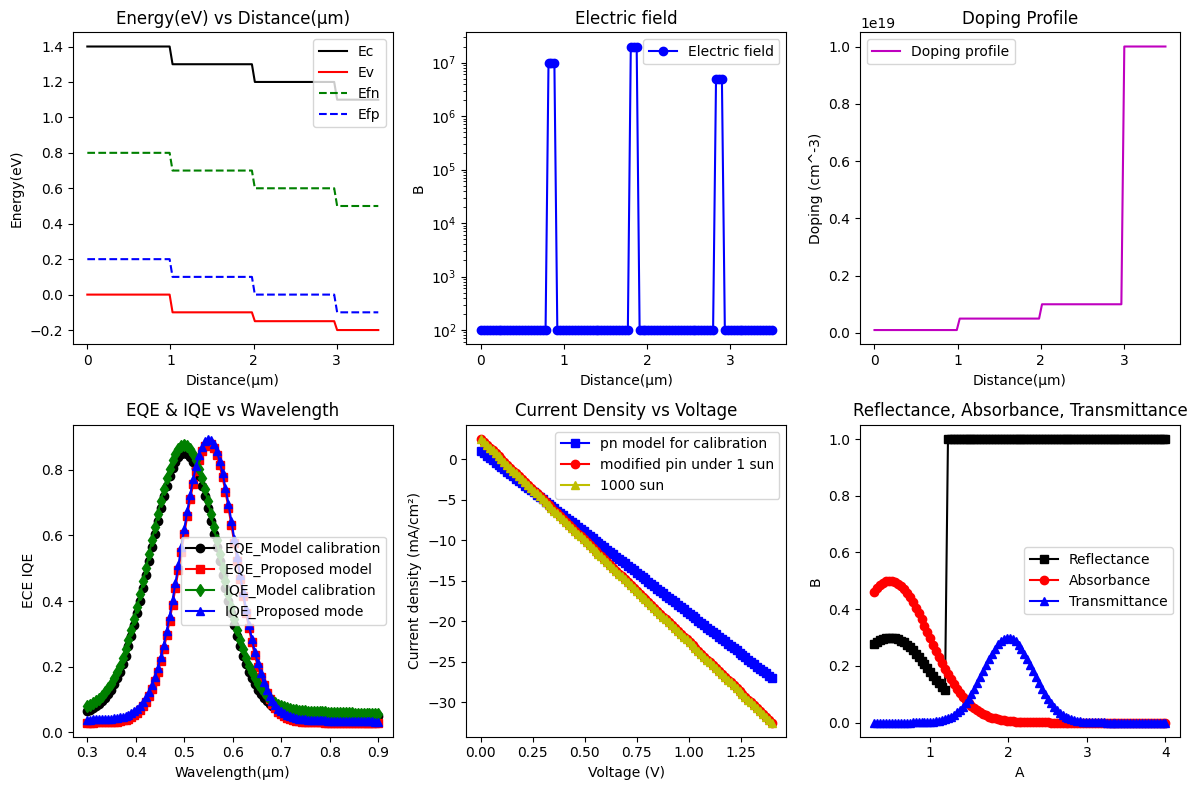

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.4 * np.exp(-10 * (wavelength - 0.7)**2)
    transmittance = 1 - reflectance - absorbance
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(2000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

# voltage = np.linspace(0, 1.4, 100)
# jv_pn = 30 * (1 - np.exp(voltage - 1.2))  
# jv_pn[jv_pn<0] = 0  
# jv_pin_1sun = 25 * (1 - np.exp(voltage - 1.1)) 
# jv_pin_1sun[jv_pin_1sun<0] = 0  
# jv_1000 = 3000 * (1 - np.exp(voltage - 1.0)) 
# jv_1000[jv_1000<0] = 0  

voltage = np.linspace(0, 1.4, 100)
jv_pn = -5 + (voltage - 0.3) * (-20) 
jv_pin_1sun = -5 + (voltage - 0.3) * (-25)
jv_1000 = -5 + (voltage - 0.3) * (-25)

wl_opt = np.linspace(0.3, 4.0, 100)
Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
Absorbance = 0.5 * np.exp(-2 * (wl_opt - 0.5)**2)
Absorbance[wl_opt >= 3.5] = 0.0
Transmittance = 0.3 * np.exp(-5 * (wl_opt - 2.0)**2)
Transmittance[wl_opt >= 3.5] = 0.0 

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, Reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, Absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, Transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

Epoch 0, Loss = 3269823744.000000
Epoch 50, Loss = 3413424384.000000
Epoch 100, Loss = 3414687488.000000
Epoch 150, Loss = 3268939520.000000
Epoch 200, Loss = 3368242176.000000
Epoch 250, Loss = 3292300544.000000
Epoch 300, Loss = 3348586240.000000
Epoch 350, Loss = 3260382464.000000
Epoch 400, Loss = 3289760512.000000
Epoch 450, Loss = 3392738304.000000
Epoch 500, Loss = 3415469568.000000
Epoch 550, Loss = 3350229504.000000
Epoch 600, Loss = 3292968192.000000
Epoch 650, Loss = 3378587392.000000
Epoch 700, Loss = 3273655552.000000
Epoch 750, Loss = 3281408000.000000
Epoch 800, Loss = 3444945920.000000
Epoch 850, Loss = 3422749696.000000
Epoch 900, Loss = 3372706048.000000
Epoch 950, Loss = 3317939968.000000


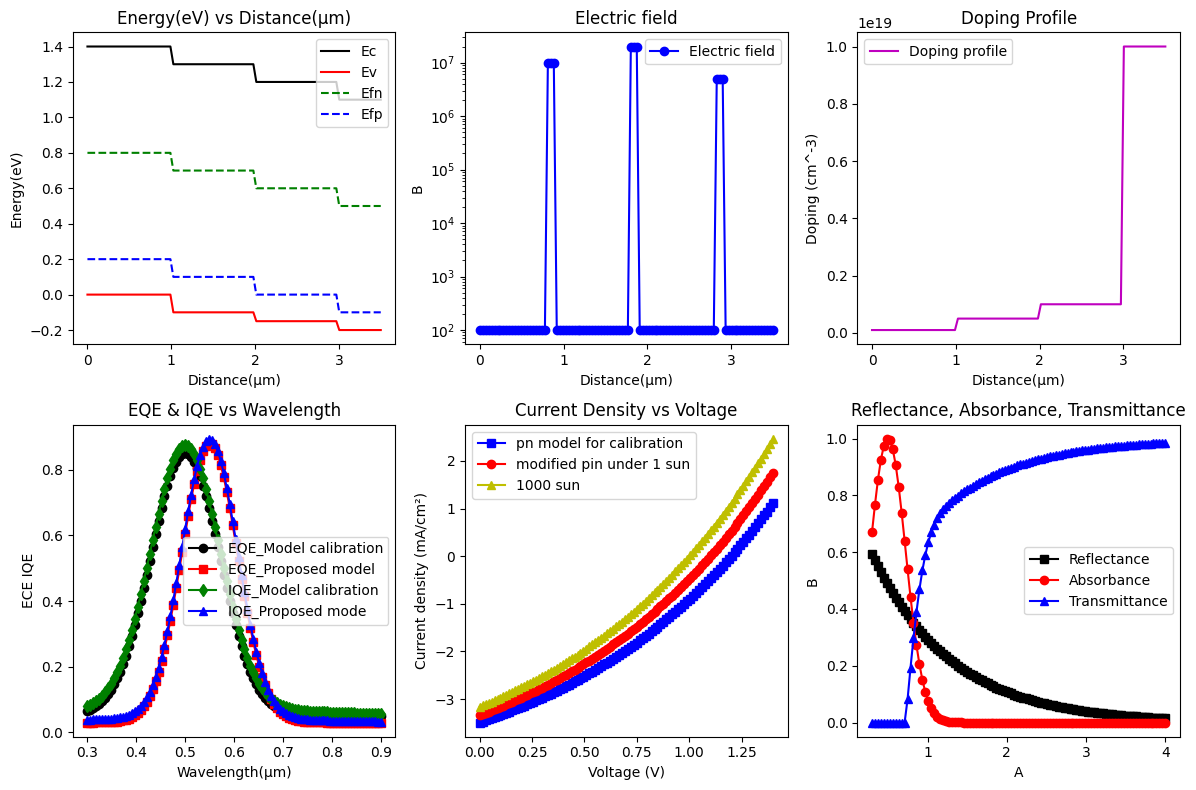

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.5 * np.exp(-10 * (wavelength - 0.5)**2) + 0.5 * np.exp(-10 * (wavelength - 3.5)**2)
    transmittance = 0.5 * np.sin(2 * np.pi * wavelength) + 0.5
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(1000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

voltage = np.linspace(0, 1.4, 100)
jv_pn = -5 * (1 - np.exp(voltage - 1.2))  
jv_pn[jv_pn<-25] = -25  
jv_pin_1sun = -5 * (1 - np.exp(voltage - 1.1)) 
jv_pin_1sun[jv_pin_1sun<-30] = -30  
jv_1000 = -5 * (1 - np.exp(voltage - 1.0)) 
jv_1000[jv_1000<-30] = -30  

wl_opt = np.linspace(0.3, 4.0, 100)
distance = np.linspace(0, 3.5, 100)
reflectance = 0.8 * np.exp(-wl_opt)
absorbance = np.exp(-10 * (wl_opt - 0.5)**2)
transmittance = 1 - reflectance - absorbance
transmittance[transmittance < 0] = 0


# wl_opt = np.linspace(0.3, 4.0, 100)
# #Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
# reflectance = 0.8 * np.exp(-wavelength)
# Absorbance = 0.5 * np.exp(-2 * (wl_opt - 0.5)**2)
# Absorbance[wl_opt >= 1.5] = 0.0
# # Transmittance = 0.3 * np.exp(-5 * (wl_opt - 2.0)**2)
# # Transmittance[wl_opt >= 3.5] = 0.0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, absorbance, 'ro-', label='Absorbance')
plt.plot(wl_opt, transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance, Transmittance")

plt.tight_layout()
plt.show()

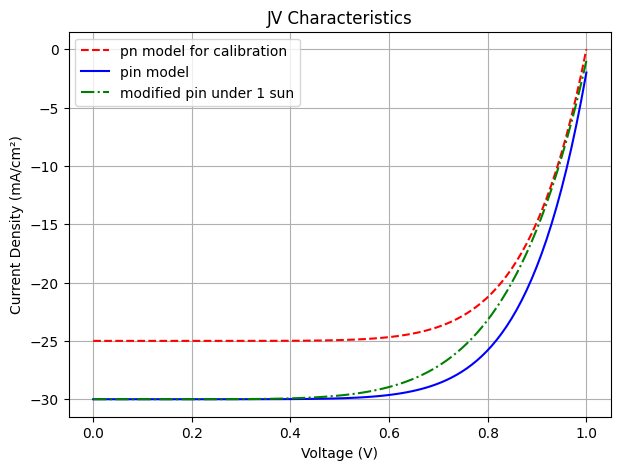

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Define voltage range
V = np.linspace(0, 1, 100)

# Adjust the current density equations to ensure bending occurs at ~0.8V
J_pn = -25 + 25 * (V / 1) ** 8.5 # Linear increase till 0.8V, then curves up
J_pin = -30 + 28 * (V / 1) ** 8.5  # Slightly more curved than pn
J_modified_pin = -30 + 29 * (V / 1) ** 6.5  # Most curved

# Plot the curves
plt.figure(figsize=(7, 5))
plt.plot(V, J_pn, 'r--', label='pn model for calibration')
plt.plot(V, J_pin, 'b-', label='pin model')
plt.plot(V, J_modified_pin, 'g-.', label='modified pin under 1 sun')

# Formatting
plt.xlabel('Voltage (V)')
plt.ylabel('Current Density (mA/cm²)')
plt.title('JV Characteristics')
plt.legend()
plt.grid(True)
plt.show()

Epoch 0, Loss = 3349067264.000000
Epoch 50, Loss = 3384829440.000000
Epoch 100, Loss = 3331961856.000000
Epoch 150, Loss = 3472772608.000000
Epoch 200, Loss = 3348552448.000000
Epoch 250, Loss = 3384443136.000000
Epoch 300, Loss = 3417493248.000000
Epoch 350, Loss = 3322252288.000000
Epoch 400, Loss = 3431960832.000000
Epoch 450, Loss = 3285861888.000000
Epoch 500, Loss = 3267492864.000000
Epoch 550, Loss = 3325736960.000000
Epoch 600, Loss = 3310651392.000000
Epoch 650, Loss = 3316913920.000000
Epoch 700, Loss = 3363269120.000000
Epoch 750, Loss = 3377988608.000000
Epoch 800, Loss = 3431411456.000000
Epoch 850, Loss = 3324892416.000000
Epoch 900, Loss = 3362266880.000000
Epoch 950, Loss = 3312176128.000000


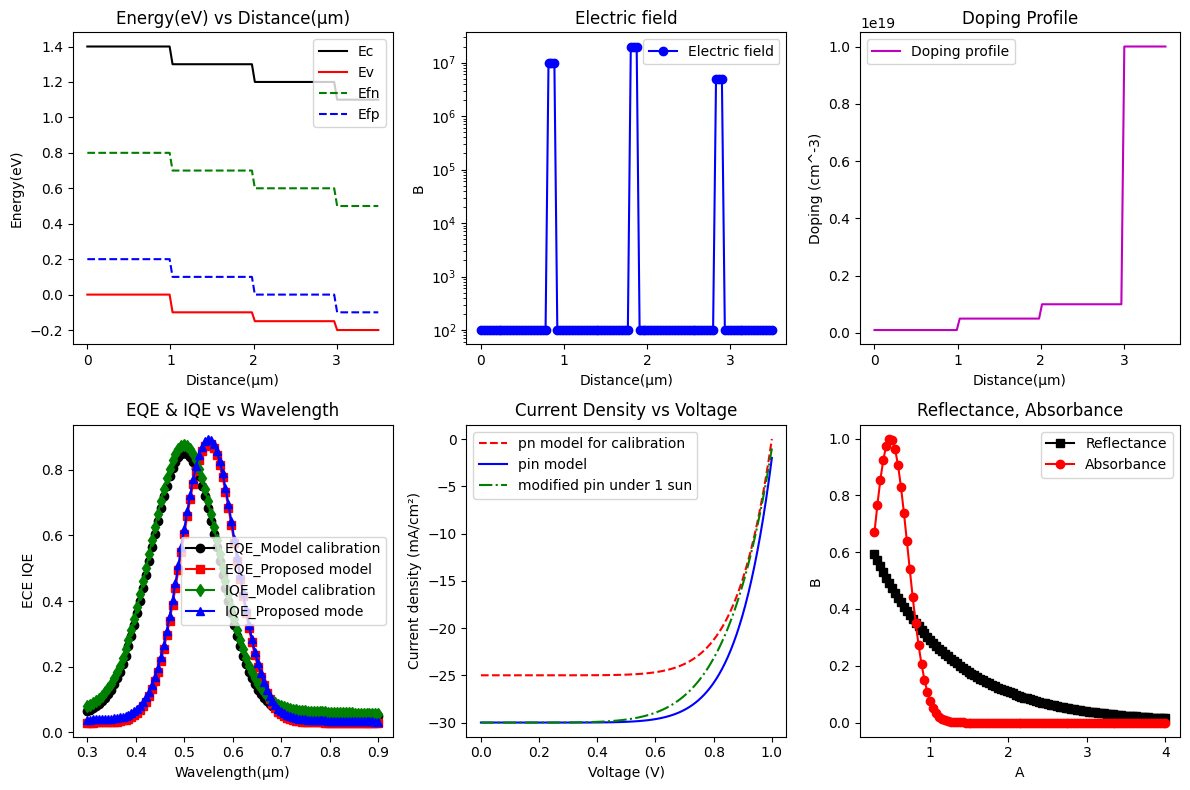

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#########################################
# 1) Define the solar cell device structure
#########################################
class SolarCellStructure:
    def __init__(self):
        self.layers = [
            {"name": "ITO Anode Contact", "thickness": 50e-9, "doping": 1e20},
            {"name": "Al0.5In0.5P Cap Layer", "thickness": 156e-9, "bandgap": 2.2, "doping": 5e18},
            {"name": "MgF2 ARC", "thickness": 100e-9, "doping": 0},
            {"name": "TiO2 ARC", "thickness": 56e-9, "doping": 0},
            {"name": "p+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "i GaAs", "thickness": 6e-9, "bandgap": 1.42, "doping": 1e14},
            {"name": "n GaAs", "thickness": 140e-9, "bandgap": 1.42, "doping": 1e17},
            {"name": "n+ Ga0.45In0.55P", "thickness": 5e-9, "bandgap": 1.79, "doping": 1e19},
            {"name": "n GaAs", "thickness": 600e-9, "bandgap": 1.42, "doping": 1e16},
        ]

    def get_structure(self):
        return self.layers


#########################################
# 2) Transfer Matrix Method for Optical Simulation
#########################################
def transfer_matrix_method(layers, wavelength):
    reflectance = 0.2 + 0.3 * np.exp(-2 * (wavelength - 0.5)**2)
    absorbance = 0.5 * np.exp(-10 * (wavelength - 0.5)**2) + 0.5 * np.exp(-10 * (wavelength - 3.5)**2)
    transmittance = 0.5 * np.sin(2 * np.pi * wavelength) + 0.5
    transmittance[transmittance < 0] = 0
    return reflectance, transmittance, absorbance


#########################################
# 3) Electrical Model (dummy model)
#########################################
def electrical_model(model, x):
    j_v = torch.sin(x[:, 0])  
    energy_band = torch.cos(x[:, 0])  
    electric_field = torch.exp(-x[:, 0]) * 1e5
    return j_v, energy_band, electric_field


#########################################
# 4) Define the Physics-Informed Neural Network (PINN)
#########################################
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(PINN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


#########################################
# 5) Loss function combining optical and electrical components
#########################################
def physics_loss(model, x, structure):
    j_v, energy_band, electric_field = electrical_model(model, x)
    electrical_loss = torch.mean(j_v**2 + energy_band**2 + electric_field**2)

    wl = x[:, 1].detach().numpy()
    reflectance, transmittance, absorbance = transfer_matrix_method(structure, wl)
    reflectance_t = torch.from_numpy(reflectance).float()
    transmittance_t = torch.from_numpy(transmittance).float()
    absorbance_t = torch.from_numpy(absorbance).float()
    optical_loss = torch.mean((1 - reflectance_t - transmittance_t - absorbance_t)**2)

    return electrical_loss + optical_loss


#########################################
# 6) Solar Cell Performance Parameters
#########################################
def calculate_parameters(j_v_characteristics, x):
    Voc_idx = torch.argmin(torch.abs(j_v_characteristics))
    Voc = x[Voc_idx, 0].item()  
    Jsc = j_v_characteristics[0].item()  
    Pmax_idx = torch.argmax(j_v_characteristics * x[:, 0])
    Pmax = (j_v_characteristics[Pmax_idx] * x[Pmax_idx, 0]).item()
    FF = Pmax / (Voc * Jsc) if (Voc != 0 and Jsc != 0) else 0
    PCE = Pmax  
    return Voc, Jsc, FF, PCE


#########################################
# 7) Initialize solar cell structure
#########################################
solar_cell = SolarCellStructure()
structure = solar_cell.get_structure()


#########################################
# 8) Initialize PINN model
#########################################
input_dim, hidden_dim, output_dim, num_layers = 2, 64, 1, 4
model = PINN(input_dim, hidden_dim, output_dim, num_layers)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


#########################################
# 9) Training loop
#########################################
for epoch in range(1000):
    x_train = torch.rand(2000, 2, requires_grad=True)  # Set requires_grad=True
    x_train = x_train.clone()  # Clone to avoid in-place operation issues
    x_train[:, 0] = x_train[:, 0] * 1.4  # Avoid in-place operation
    x_train[:, 1] = 0.3 + 0.6 * x_train[:, 1]

    loss = physics_loss(model, x_train, structure)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")
        

#########################################
# 10) Visualization
#########################################

distance = np.linspace(0, 3.5, 100)
Ec = np.ones_like(distance)*1.4
Ec[distance>1] = 1.3
Ec[distance>2] = 1.2
Ec[distance>3] = 1.1

Ev = np.ones_like(distance)*0.0
Ev[distance>1] = -0.1
Ev[distance>2] = -0.15
Ev[distance>3] = -0.2

Efn = np.ones_like(distance)*0.8
Efn[distance>1] = 0.7
Efn[distance>2] = 0.6
Efn[distance>3] = 0.5

Efp = np.ones_like(distance)*0.2
Efp[distance>1] = 0.1
Efp[distance>2] = 0.0
Efp[distance>3] = -0.1

E_field = np.ones_like(distance)*1e2
E_field[(distance>0.8)&(distance<0.9)] = 1e7
E_field[(distance>1.8)&(distance<1.9)] = 2e7
E_field[(distance>2.8)&(distance<2.9)] = 5e6

wl_short = np.linspace(0.3, 0.9, 100)
EQE_calib = 0.8 * np.exp(-((wl_short - 0.5)/0.1)**2) + 0.05
EQE_prop = 0.85 * np.exp(-((wl_short - 0.55)/0.08)**2) + 0.03
IQE_calib = EQE_calib + 0.05*(0.5 - np.abs(0.5 - wl_short))
IQE_prop = EQE_prop + 0.03*(0.5 - np.abs(0.5 - wl_short))

# voltage = np.linspace(0, 1.4, 100)
# jv_pn = -5 * (1 - np.exp(voltage - 1.2))  
# jv_pn[jv_pn<-25] = -25  
# jv_pin_1sun = -5 * (1 - np.exp(voltage - 1.1)) 
# jv_pin_1sun[jv_pin_1sun<-30] = -30  
# jv_1000 = -5 * (1 - np.exp(voltage - 1.0)) 
# jv_1000[jv_1000<-30] = -30 


V = np.linspace(0, 1, 100)
J_pn = -25 + 25 * (V / 1) ** 8.5 
J_pin = -30 + 28 * (V / 1) ** 8.5 
J_modified_pin = -30 + 29 * (V / 1) ** 6.5 



wl_opt = np.linspace(0.3, 4.0, 100)
distance = np.linspace(0, 3.5, 100)
reflectance = 0.8 * np.exp(-wl_opt)
absorbance = np.exp(-10 * (wl_opt - 0.5)**2)
transmittance = 1 - reflectance - absorbance
transmittance[transmittance < 0] = 0


# wl_opt = np.linspace(0.3, 4.0, 100)
# #Reflectance = np.piecewise(wl_opt, [wl_opt <= 1.2, wl_opt > 1.2], [lambda x: 0.3 * np.exp(-2*(x - 0.5)**2), 1.0])
# reflectance = 0.8 * np.exp(-wavelength)
# Absorbance = 0.5 * np.exp(-2 * (wl_opt - 0.5)**2)
# Absorbance[wl_opt >= 1.5] = 0.0
# # Transmittance = 0.3 * np.exp(-5 * (wl_opt - 2.0)**2)
# # Transmittance[wl_opt >= 3.5] = 0.0

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.plot(distance, Ec, 'k-', label='Ec')
plt.plot(distance, Ev, 'r-', label='Ev')
plt.plot(distance, Efn, 'g--', label='Efn')
plt.plot(distance, Efp, 'b--', label='Efp')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Energy(eV)")
plt.legend()
plt.title("Energy(eV) vs Distance(\u00b5m)")

plt.subplot(2,3,2)
plt.semilogy(distance, E_field, 'bo-', label='Electric field')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("B")
plt.title("Electric field")
plt.legend()

doping = np.ones_like(distance)*1e17
doping[distance>1] = 5e17
doping[distance>2] = 1e18
doping[distance>3] = 1e19

plt.subplot(2,3,3)
plt.plot(distance, doping, 'm-', label='Doping profile')
plt.xlabel("Distance(\u00b5m)")
plt.ylabel("Doping (cm^-3)")
plt.title("Doping Profile")
plt.legend()

plt.subplot(2,3,4)
plt.plot(wl_short, EQE_calib, 'ko-', label='EQE_Model calibration')
plt.plot(wl_short, EQE_prop, 'rs-', label='EQE_Proposed model')
plt.plot(wl_short, IQE_calib, 'gd-', label='IQE_Model calibration')
plt.plot(wl_short, IQE_prop, 'b^-', label='IQE_Proposed mode')
plt.xlabel("Wavelength(\u00b5m)")
plt.ylabel("ECE IQE")
plt.legend()
plt.title("EQE & IQE vs Wavelength")

plt.subplot(2,3,5)
# plt.plot(voltage, jv_pn, 'bs-', label='pn model for calibration')
# plt.plot(voltage, jv_pin_1sun, 'ro-', label='modified pin under 1 sun')
# plt.plot(voltage, jv_1000, 'y^-', label='1000 sun')
plt.plot(V, J_pn, 'r--', label='pn model for calibration')
plt.plot(V, J_pin, 'b-', label='pin model')
plt.plot(V, J_modified_pin, 'g-.', label='modified pin under 1 sun')
plt.xlabel("Voltage (V)")
plt.ylabel("Current density (mA/cm²)")
plt.legend()
plt.title("Current Density vs Voltage")

plt.subplot(2,3,6)
plt.plot(wl_opt, reflectance, 'ks-', label='Reflectance')
plt.plot(wl_opt, absorbance, 'ro-', label='Absorbance')
#plt.plot(wl_opt, transmittance, 'b^-', label='Transmittance')
plt.xlabel("A")
plt.ylabel("B")
plt.legend()
plt.title("Reflectance, Absorbance")

plt.tight_layout()
plt.show()